# TCN GWO-Optimized: No-RevIN vs RevIN Per-Patient Comparison (H=10)

**Author:** Ibrahim Hanafy  
**Date:** August 2026  

**Goal:** Run the GWO-optimized TCN on all 21 patients with and without RevIN,
then compare not just numbers but actual signal tracking quality.

| Parameter | Value |
|-----------|-------|
| `n_filters` | 256 |
| `dropout` | 0.109 |
| `lr` | 0.002066 |
| `n_blocks` | 4 |
| `kernel_size` | 3 |
| `batch_size` | 128 |

**Structure:**
1. Part A — Train & evaluate **without RevIN** (standard TCN)
2. Part B — Train & evaluate **with RevIN** (TCN + RevIN wrapper)
3. Part C — Comparison: metrics tables, signal overlays, zoomed waveforms

## 1 — Imports & Setup

In [1]:
! pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.5 MB/s eta 0:00:00


In [2]:
import os, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2 — Configuration

In [4]:
# ── Dataset ──────────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10

PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21

HORIZON = 10

# ── GWO-Optimized Hyperparameters ─────────────────────────────────────────
NUM_FILTERS   = 256
DROPOUT_RATE  = 0.109
LEARNING_RATE = 0.002066
NUM_BLOCKS    = 4
KERNEL_SIZE   = 3
BATCH_SIZE    = 128

EPOCHS   = 200
PATIENCE = 50

PLOT_DIR = 'plots_revin_comparison'
os.makedirs(PLOT_DIR, exist_ok=True)

# Select patients for detailed signal plots
VIZ_PATIENTS = ['100', '103', '109', '114', '101']
# 103,109,114 = best performers; 101 = worst (GWO regression); 100 = baseline

print(f'Config    : GWO-Optimized + RevIN Comparison')
print(f'Patients  : {len(PATIENTS)}')
print(f'Horizon   : H={HORIZON}')
print(f'TCN       : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, kernel={KERNEL_SIZE}')
print(f'Dropout   : {DROPOUT_RATE}')
print(f'Training  : epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}, lr={LEARNING_RATE:.6f}')
print(f'Viz patients: {VIZ_PATIENTS}')

Config    : GWO-Optimized + RevIN Comparison
Patients  : 21
Horizon   : H=10
TCN       : blocks=4, filters=256, kernel=3
Dropout   : 0.109
Training  : epochs=200, patience=50, batch=128, lr=0.002066
Viz patients: ['100', '103', '109', '114', '101']


## 3 — Data Pipeline

In [5]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


print('Data pipeline defined.')

Data pipeline defined.


In [6]:
# ── Load all patients ─────────────────────────────────────────────────────
patient_signals = {}
print(f'Loading {len(PATIENTS)} patients...')

for rid in tqdm(PATIENTS, desc='Patients'):
    raw = load_ecg_signal(rid, DATA_DIR, TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(raw, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} patients loaded.')

Loading 21 patients...


Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 101 | train=40,000  val=10,000  test=50,000
  Patient 102 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 104 | train=40,000  val=10,000  test=50,000
  Patient 105 | train=40,000  val=10,000  test=50,000
  Patient 106 | train=40,000  val=10,000  test=50,000
  Patient 107 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 109 | train=40,000  val=10,000  test=50,000
  Patient 112 | train=40,000  val=10,000  test=50,000
  Patient 113 | train=40,000  val=10,000  test=50,000
  Patient 114 | train=40,000  val=10,000  test=50,000
  Patient 115 | train=40,000  val=10,000  test=50,000
  Patient 116 | train=40,000  val=10,000  test=50,000
  Patient 117 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000  val=10,000  test=50,000
  Patient 121 | train=40,000  val=10,000  test=50,000
  Patient 122 | train=40,000

## 4 — Model Architecture

In [7]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size, n_blocks, n_filters, kernel_size, dropout_rate, learning_rate):
    """Standard TCN (no RevIN)."""
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(n_blocks):
        x = residual_block(x, n_filters, kernel_size, 2 ** i, dropout_rate)
    x = x[:, -1, :]
    x = Dense(n_filters, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_H{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse')
    return model


print('Standard TCN defined.')

Standard TCN defined.


In [8]:
class TCNWithRevIN(tf.keras.Model):
    """TCN wrapped with Reversible Instance Normalization.

    Normalizes each input window by its own mean/std before the TCN,
    then denormalizes the output back to the original scale.
    """

    def __init__(self, lookback, output_size, n_blocks, n_filters,
                 kernel_size, dropout_rate, learning_rate, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps
        self.lookback = lookback
        self.horizon  = output_size
        self._lr = learning_rate

        # Learnable affine parameters
        self.revin_gamma = self.add_weight(
            name='revin_gamma', shape=(1, 1, 1), initializer='ones', trainable=True)
        self.revin_beta = self.add_weight(
            name='revin_beta', shape=(1, 1, 1), initializer='zeros', trainable=True)

        # TCN backbone
        self.backbone = self._build_backbone(lookback, output_size,
                                             n_blocks, n_filters,
                                             kernel_size, dropout_rate)

    def _build_backbone(self, lookback, output_size, n_blocks, n_filters,
                        kernel_size, dropout_rate):
        inp = Input(shape=(lookback, 1))
        x = inp
        for i in range(n_blocks):
            x = residual_block(x, n_filters, kernel_size, 2 ** i, dropout_rate)
        x = x[:, -1, :]
        x = Dense(n_filters, activation='relu')(x)
        out = Dense(output_size)(x)
        return Model(inp, out, name='TCN_backbone')

    def call(self, x, training=False):
        # x shape: (batch, lookback, 1)
        # ── RevIN: normalize ──────────────────────────────────────────────
        mean = tf.reduce_mean(x, axis=1, keepdims=True)   # (batch, 1, 1)
        std  = tf.math.reduce_std(x, axis=1, keepdims=True) + self.eps
        x_norm = (x - mean) / std * self.revin_gamma + self.revin_beta

        # ── TCN backbone ──────────────────────────────────────────────────
        out = self.backbone(x_norm, training=training)  # (batch, horizon)

        # ── RevIN: denormalize ────────────────────────────────────────────
        mean_sq = tf.squeeze(mean, axis=[1, 2])  # (batch,)
        std_sq  = tf.squeeze(std, axis=[1, 2])
        gamma_sq = tf.squeeze(self.revin_gamma)
        beta_sq  = tf.squeeze(self.revin_beta)

        out = (out - beta_sq) / (gamma_sq + self.eps) * tf.expand_dims(std_sq, 1) + tf.expand_dims(mean_sq, 1)
        return out


def build_tcn_revin(lookback, output_size, n_blocks, n_filters,
                    kernel_size, dropout_rate, learning_rate):
    """Build and compile TCN+RevIN model."""
    model = TCNWithRevIN(lookback, output_size, n_blocks, n_filters,
                         kernel_size, dropout_rate, learning_rate,
                         name='TCN_RevIN')
    # Trigger build
    _ = model(tf.zeros((1, lookback, 1)))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse')
    return model


# Sanity check
_plain = build_tcn(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE, DROPOUT_RATE, LEARNING_RATE)
_revin = build_tcn_revin(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE, DROPOUT_RATE, LEARNING_RATE)
print(f'TCN (no RevIN): {_plain.count_params():,} params')
print(f'TCN + RevIN:    {sum(np.prod(v.shape) for v in _revin.trainable_variables):,} params (+2 affine)')
del _plain, _revin
tf.keras.backend.clear_session()

I0000 00:00:1786865659.577364      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786865659.580229      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TCN (no RevIN): 1,456,138 params
TCN + RevIN:    1,452,044 params (+2 affine)


## 5 — Training Helper

In [9]:
def train_and_evaluate_patient(rid, use_revin=False):
    """Train one model for one patient, return metrics + predictions."""
    tf.keras.backend.clear_session()
    gc.collect()

    tr = patient_signals[rid]['train']
    vl = patient_signals[rid]['val']
    te = patient_signals[rid]['test']

    X_tr, y_tr = make_multistep_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_multistep_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_multistep_sequences(te, LOOKBACK, HORIZON)

    X_tr_r = X_tr.reshape(-1, X_tr.shape[1], 1)
    X_vl_r = X_vl.reshape(-1, X_vl.shape[1], 1)
    X_te_r = X_te.reshape(-1, X_te.shape[1], 1)

    t0 = time.time()
    if use_revin:
        model = build_tcn_revin(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS,
                                KERNEL_SIZE, DROPOUT_RATE, LEARNING_RATE)
    else:
        model = build_tcn(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS,
                          KERNEL_SIZE, DROPOUT_RATE, LEARNING_RATE)

    history = model.fit(
        X_tr_r, y_tr,
        validation_data=(X_vl_r, y_vl),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=25, min_lr=1e-6),
        ],
        verbose=0
    )

    preds = model.predict(X_te_r, batch_size=2048, verbose=0)
    elapsed = time.time() - t0

    m = compute_metrics(y_te, preds)
    m['Time_s'] = round(elapsed, 2)
    m['Epochs_trained'] = len(history.history['loss'])

    del model
    gc.collect()

    return m, preds, y_te, history


print('Training helper defined.')

Training helper defined.


---
# PART A — No RevIN (Standard TCN)
---

In [10]:
results_no_revin = []
preds_no_revin   = {}   # {patient_id: (y_true, y_pred)}
hist_no_revin    = {}

print('=' * 80)
print('  PART A: TCN (No RevIN) — GWO-Optimized Config')
print('=' * 80)
print(f'Running: {len(PATIENTS)} patients × H={HORIZON}\n')

for rid in tqdm(PATIENTS, desc='No RevIN'):
    m, preds, y_te, hist = train_and_evaluate_patient(rid, use_revin=False)
    results_no_revin.append({'Patient': rid, **m})
    preds_no_revin[rid] = (y_te, preds)
    hist_no_revin[rid] = hist.history
    tqdm.write(f'  Patient {rid} | R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  '
               f'MAE={m["MAE"]:.4f}  ({m["Epochs_trained"]} ep, {m["Time_s"]:.1f}s)')

df_no_revin = pd.DataFrame(results_no_revin)
print(f'\n--- No RevIN Summary (H={HORIZON}) ---')
print(f'Mean RMSE : {df_no_revin.RMSE.mean():.6f} ± {df_no_revin.RMSE.std():.6f}')
print(f'Mean MAE  : {df_no_revin.MAE.mean():.6f} ± {df_no_revin.MAE.std():.6f}')
print(f'Mean R²   : {df_no_revin.R2.mean():.4f} ± {df_no_revin.R2.std():.4f}')
print(f'Mean Time : {df_no_revin.Time_s.mean():.1f}s')

  PART A: TCN (No RevIN) — GWO-Optimized Config
Running: 21 patients × H=10



No RevIN:   0%|          | 0/21 [00:00<?, ?it/s]

I0000 00:00:1786865678.787000      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-08-16 07:41:19.889698: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng18{k11=0} for conv (f32[256,16384,1,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,16384,1,4]{3,2,1,0}, f32[256,256,1,3]{3,2,1,0}), window={size=1x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-16 07:41:20.669701: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.780099445s
Trying algorithm eng18{k11=0} for conv (f32[256,16384,1,2]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,16384,1,4]{3,2,1,0}, f32

  Patient 100 | R²=0.9272  RMSE=0.0259  MAE=0.0122  (121 ep, 421.9s)
  Patient 101 | R²=0.7235  RMSE=0.0578  MAE=0.0181  (106 ep, 365.9s)
  Patient 102 | R²=0.8323  RMSE=0.0277  MAE=0.0106  (200 ep, 659.6s)
  Patient 103 | R²=0.9782  RMSE=0.0171  MAE=0.0082  (200 ep, 669.7s)
  Patient 104 | R²=0.7385  RMSE=0.0533  MAE=0.0318  (86 ep, 301.5s)
  Patient 105 | R²=0.8911  RMSE=0.0380  MAE=0.0161  (141 ep, 480.5s)
  Patient 106 | R²=0.8609  RMSE=0.0348  MAE=0.0136  (171 ep, 575.3s)
  Patient 107 | R²=0.9448  RMSE=0.0309  MAE=0.0132  (200 ep, 662.7s)
  Patient 108 | R²=0.7640  RMSE=0.0441  MAE=0.0224  (133 ep, 450.6s)
  Patient 109 | R²=0.9871  RMSE=0.0156  MAE=0.0081  (165 ep, 555.4s)
  Patient 112 | R²=0.8992  RMSE=0.0365  MAE=0.0175  (200 ep, 668.6s)
  Patient 113 | R²=0.9759  RMSE=0.0201  MAE=0.0072  (200 ep, 668.5s)
  Patient 114 | R²=0.9595  RMSE=0.0131  MAE=0.0050  (200 ep, 660.6s)
  Patient 115 | R²=0.8875  RMSE=0.0284  MAE=0.0094  (199 ep, 667.2s)
  Patient 116 | R²=0.9300  RMSE=0.0

---
# PART B — With RevIN (TCN + RevIN)
---

In [11]:
results_revin = []
preds_revin   = {}   # {patient_id: (y_true, y_pred)}
hist_revin    = {}

print('=' * 80)
print('  PART B: TCN + RevIN — GWO-Optimized Config')
print('=' * 80)
print(f'Running: {len(PATIENTS)} patients × H={HORIZON}\n')

for rid in tqdm(PATIENTS, desc='With RevIN'):
    m, preds, y_te, hist = train_and_evaluate_patient(rid, use_revin=True)
    results_revin.append({'Patient': rid, **m})
    preds_revin[rid] = (y_te, preds)
    hist_revin[rid] = hist.history
    tqdm.write(f'  Patient {rid} | R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  '
               f'MAE={m["MAE"]:.4f}  ({m["Epochs_trained"]} ep, {m["Time_s"]:.1f}s)')

df_revin = pd.DataFrame(results_revin)
print(f'\n--- RevIN Summary (H={HORIZON}) ---')
print(f'Mean RMSE : {df_revin.RMSE.mean():.6f} ± {df_revin.RMSE.std():.6f}')
print(f'Mean MAE  : {df_revin.MAE.mean():.6f} ± {df_revin.MAE.std():.6f}')
print(f'Mean R²   : {df_revin.R2.mean():.4f} ± {df_revin.R2.std():.4f}')
print(f'Mean Time : {df_revin.Time_s.mean():.1f}s')

  PART B: TCN + RevIN — GWO-Optimized Config
Running: 21 patients × H=10



With RevIN:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | R²=0.8936  RMSE=0.0313  MAE=0.0131  (187 ep, 643.0s)
  Patient 101 | R²=0.8066  RMSE=0.0483  MAE=0.0152  (56 ep, 212.3s)
  Patient 102 | R²=0.7617  RMSE=0.0330  MAE=0.0138  (91 ep, 327.5s)
  Patient 103 | R²=0.9508  RMSE=0.0257  MAE=0.0116  (173 ep, 598.5s)
  Patient 104 | R²=0.6620  RMSE=0.0606  MAE=0.0311  (58 ep, 218.9s)
  Patient 105 | R²=0.8503  RMSE=0.0446  MAE=0.0195  (76 ep, 279.2s)
  Patient 106 | R²=0.8174  RMSE=0.0399  MAE=0.0147  (100 ep, 356.3s)
  Patient 107 | R²=0.9144  RMSE=0.0385  MAE=0.0180  (79 ep, 287.9s)
  Patient 108 | R²=0.7064  RMSE=0.0491  MAE=0.0229  (59 ep, 221.9s)
  Patient 109 | R²=0.9615  RMSE=0.0269  MAE=0.0130  (95 ep, 340.2s)
  Patient 112 | R²=0.8886  RMSE=0.0383  MAE=0.0197  (76 ep, 279.3s)
  Patient 113 | R²=0.9007  RMSE=0.0408  MAE=0.0104  (200 ep, 685.9s)
  Patient 114 | R²=0.9136  RMSE=0.0191  MAE=0.0067  (115 ep, 408.8s)
  Patient 115 | R²=0.8473  RMSE=0.0331  MAE=0.0111  (78 ep, 285.6s)
  Patient 116 | R²=0.8782  RMSE=0.0451  MAE

---
# PART C — Comparison & Visualization
---

## 6 — Summary Table & Statistics

In [12]:
# ── Per-patient comparison table ──────────────────────────────────────────
df_cmp = df_no_revin[['Patient']].copy()
df_cmp['NoRevIN_RMSE'] = df_no_revin.RMSE.values
df_cmp['RevIN_RMSE']   = df_revin.RMSE.values
df_cmp['RMSE_Δ%']      = ((df_revin.RMSE.values - df_no_revin.RMSE.values) / df_no_revin.RMSE.values * 100).round(2)
df_cmp['NoRevIN_MAE']  = df_no_revin.MAE.values
df_cmp['RevIN_MAE']    = df_revin.MAE.values
df_cmp['MAE_Δ%']       = ((df_revin.MAE.values - df_no_revin.MAE.values) / df_no_revin.MAE.values * 100).round(2)
df_cmp['NoRevIN_R2']   = df_no_revin.R2.values
df_cmp['RevIN_R2']     = df_revin.R2.values
df_cmp['R2_Δ%']        = ((df_revin.R2.values - df_no_revin.R2.values) / df_no_revin.R2.values * 100).round(2)
df_cmp['NoRevIN_Time'] = df_no_revin.Time_s.values
df_cmp['RevIN_Time']   = df_revin.Time_s.values

print(df_cmp.to_string(index=False))

# ── Save CSV ──────────────────────────────────────────────────────────────
df_cmp.to_csv(f'{PLOT_DIR}/revin_comparison_h{HORIZON}.csv', index=False)
print(f'\nSaved to {PLOT_DIR}/revin_comparison_h{HORIZON}.csv')

# ── Mean summary ──────────────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'{"Metric":>12} {"No RevIN":>12} {"+ RevIN":>12} {"Δ%":>10}')
print(f'{"-" * 46}')
for metric in ['RMSE', 'MAE', 'R2']:
    nr = df_no_revin[metric].mean()
    wr = df_revin[metric].mean()
    pct = (wr - nr) / nr * 100
    print(f'{metric:>12} {nr:>12.6f} {wr:>12.6f} {pct:>+9.2f}%')
print(f'{"Time (s)":>12} {df_no_revin.Time_s.mean():>12.1f} {df_revin.Time_s.mean():>12.1f}')

# ── Wilcoxon test ─────────────────────────────────────────────────────────
from scipy.stats import wilcoxon
stat, p = wilcoxon(df_no_revin.RMSE.values, df_revin.RMSE.values)
sig = '✓ Significant' if p < 0.05 else '✗ Not significant'
print(f'\nWilcoxon signed-rank (RMSE): p={p:.4f} → {sig}')

# Count improved patients
improved = (df_revin.RMSE.values < df_no_revin.RMSE.values).sum()
print(f'Patients improved: {improved}/{len(PATIENTS)}')

Patient  NoRevIN_RMSE  RevIN_RMSE  RMSE_Δ%  NoRevIN_MAE  RevIN_MAE  MAE_Δ%  NoRevIN_R2  RevIN_R2  R2_Δ%  NoRevIN_Time  RevIN_Time
    100      0.025922    0.031342    20.91     0.012174   0.013142    7.95    0.927247  0.893645  -3.62        421.90      642.98
    101      0.057795    0.048336   -16.37     0.018077   0.015203  -15.90    0.723490  0.806590  11.49        365.92      212.32
    102      0.027680    0.033000    19.22     0.010617   0.013842   30.38    0.832343  0.761710  -8.49        659.63      327.50
    103      0.017142    0.025742    50.17     0.008189   0.011642   42.16    0.978169  0.950768  -2.80        669.70      598.46
    104      0.053285    0.060575    13.68     0.031807   0.031146   -2.08    0.738467  0.662013 -10.35        301.51      218.88
    105      0.038045    0.044607    17.25     0.016097   0.019490   21.08    0.891123  0.850320  -4.58        480.54      279.19
    106      0.034809    0.039880    14.57     0.013559   0.014735    8.67    0.860914  0.

## 7 — Per-Patient Metric Bar Charts

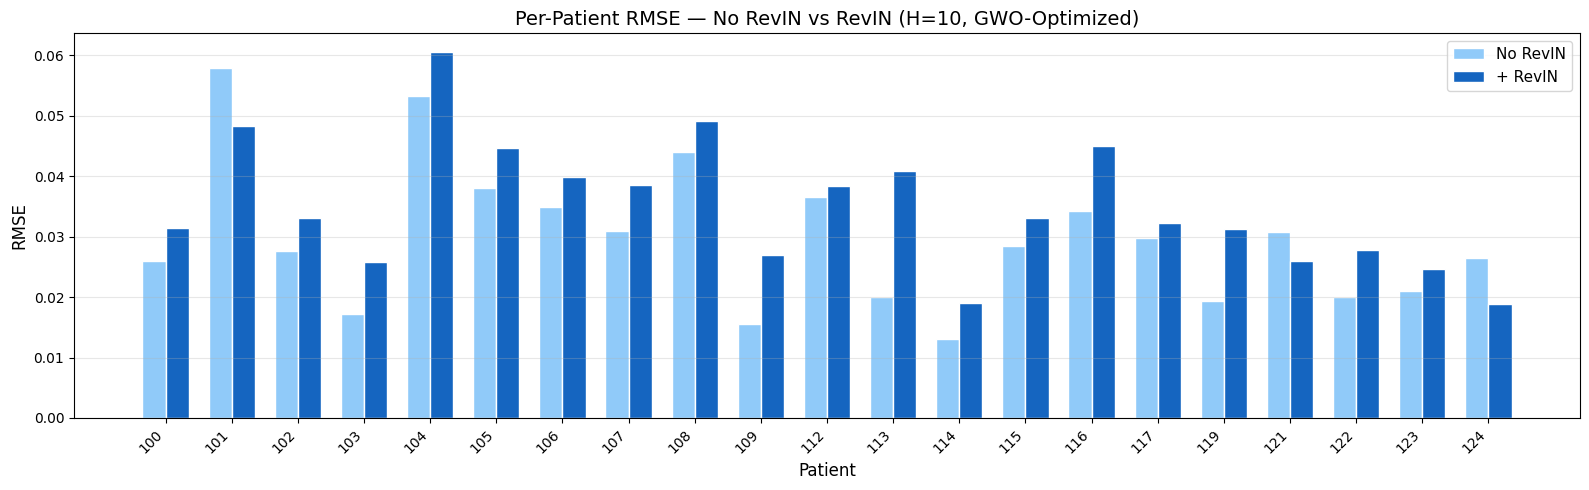

In [13]:
# ── 7.1 RMSE Bar Chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(PATIENTS))
w = 0.35

ax.bar(x - w/2, df_no_revin.RMSE.values, w,
       label='No RevIN', color='#90CAF9', edgecolor='white')
ax.bar(x + w/2, df_revin.RMSE.values, w,
       label='+ RevIN', color='#1565C0', edgecolor='white')

ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'Per-Patient RMSE — No RevIN vs RevIN (H={HORIZON}, GWO-Optimized)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(PATIENTS, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/bar_rmse.png', dpi=200, bbox_inches='tight')
plt.show()

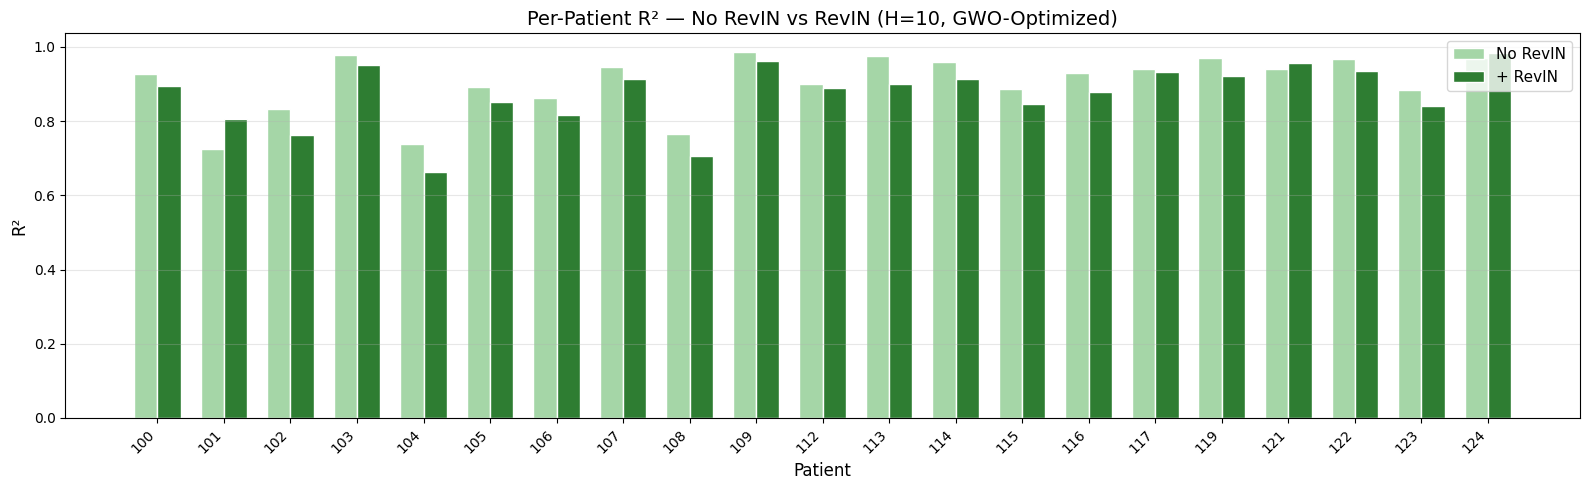

In [14]:
# ── 7.2 R² Bar Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(x - w/2, df_no_revin.R2.values, w,
       label='No RevIN', color='#A5D6A7', edgecolor='white')
ax.bar(x + w/2, df_revin.R2.values, w,
       label='+ RevIN', color='#2E7D32', edgecolor='white')

ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'Per-Patient R² — No RevIN vs RevIN (H={HORIZON}, GWO-Optimized)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(PATIENTS, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/bar_r2.png', dpi=200, bbox_inches='tight')
plt.show()

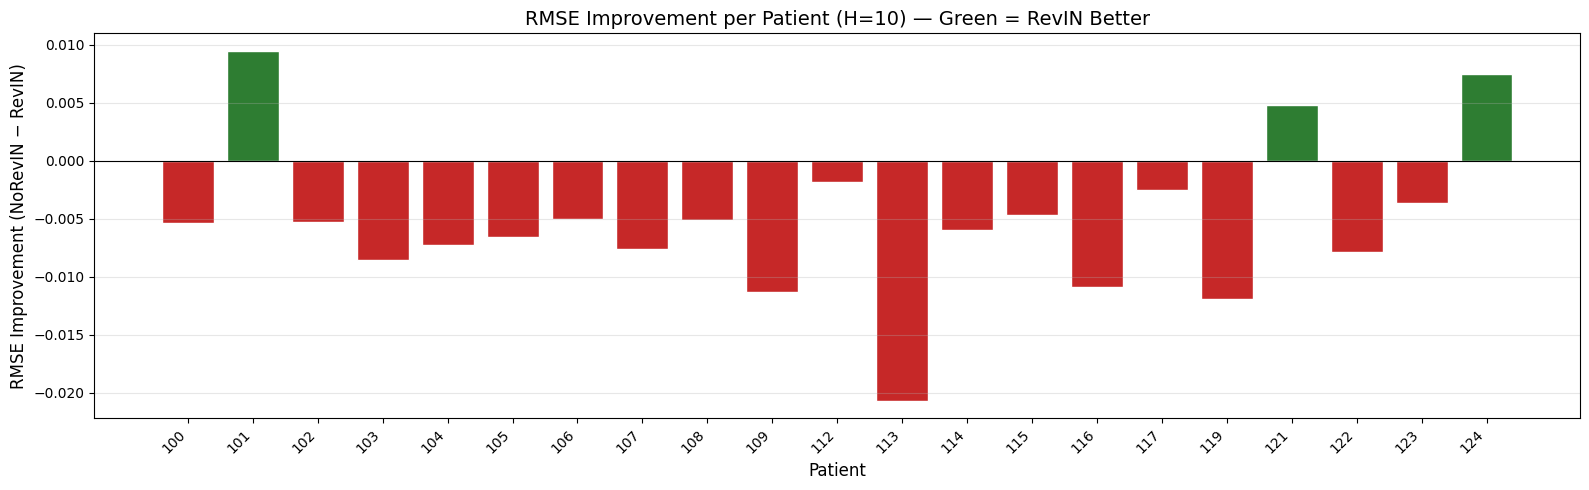

In [15]:
# ── 7.3 RMSE Improvement Waterfall ────────────────────────────────────────
improvement = df_no_revin.RMSE.values - df_revin.RMSE.values  # positive = RevIN better
colors = ['#2E7D32' if imp > 0 else '#C62828' for imp in improvement]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, improvement, color=colors, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('RMSE Improvement (NoRevIN − RevIN)', fontsize=12)
ax.set_title(f'RMSE Improvement per Patient (H={HORIZON}) — Green = RevIN Better', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(PATIENTS, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/rmse_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()

## 8 — Signal Overlay Plots: Does RevIN Actually Track Better?

This is the key question. Metrics can improve marginally while the signal
tracking is visually identical, or a small RMSE drop can hide much better
peak/valley tracking. These plots answer that directly.

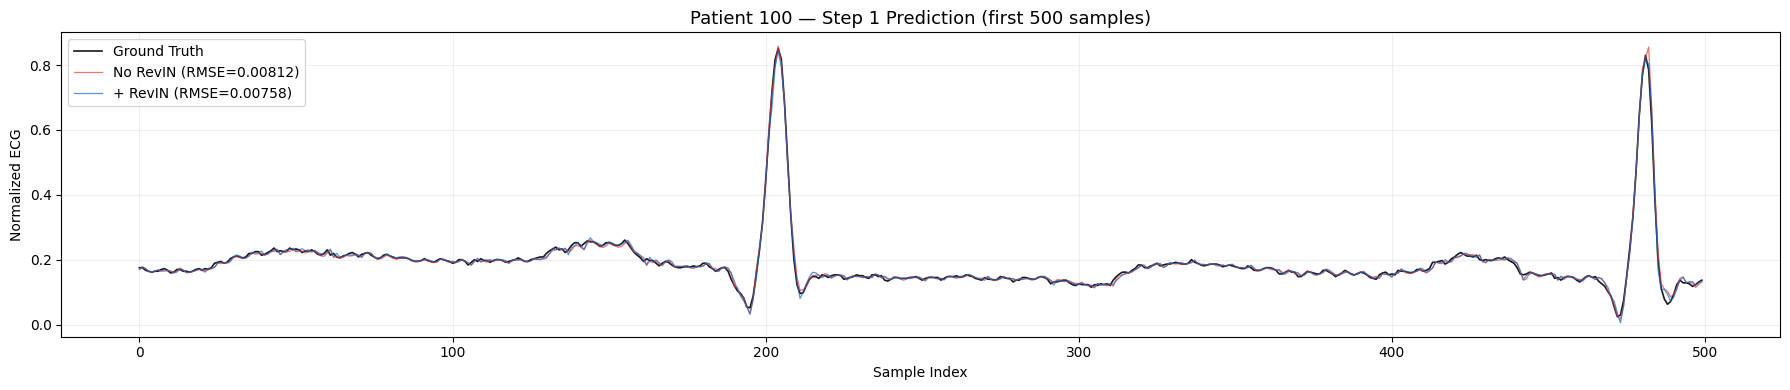

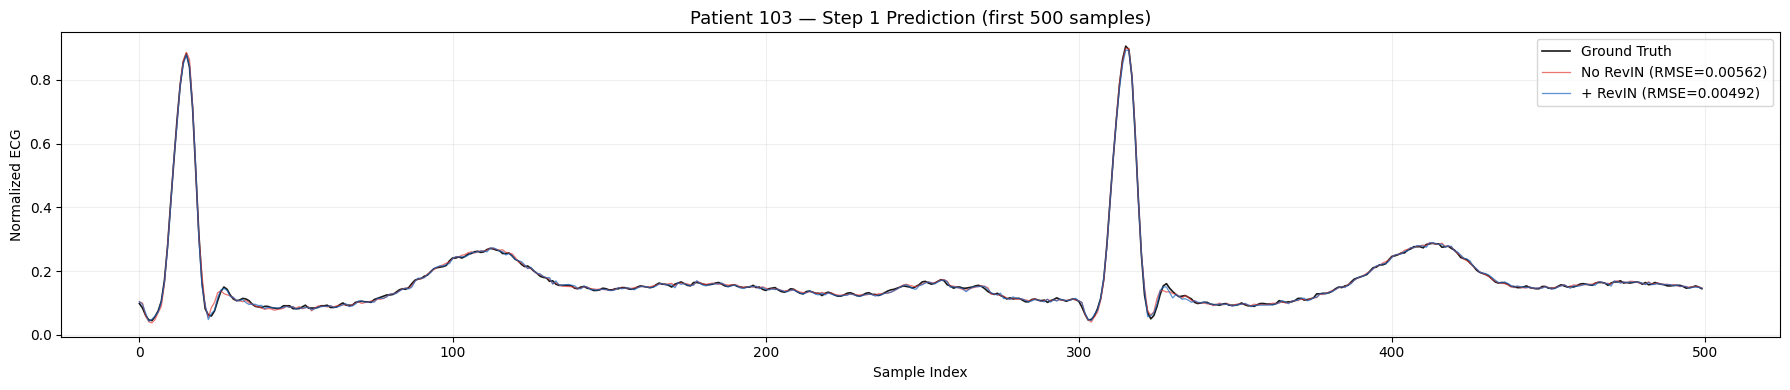

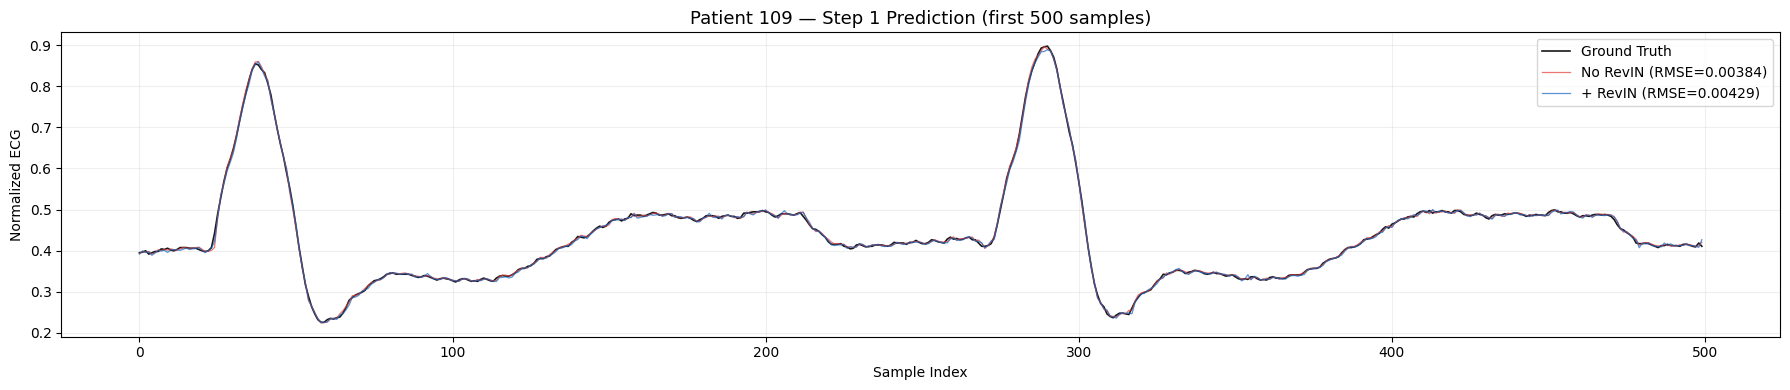

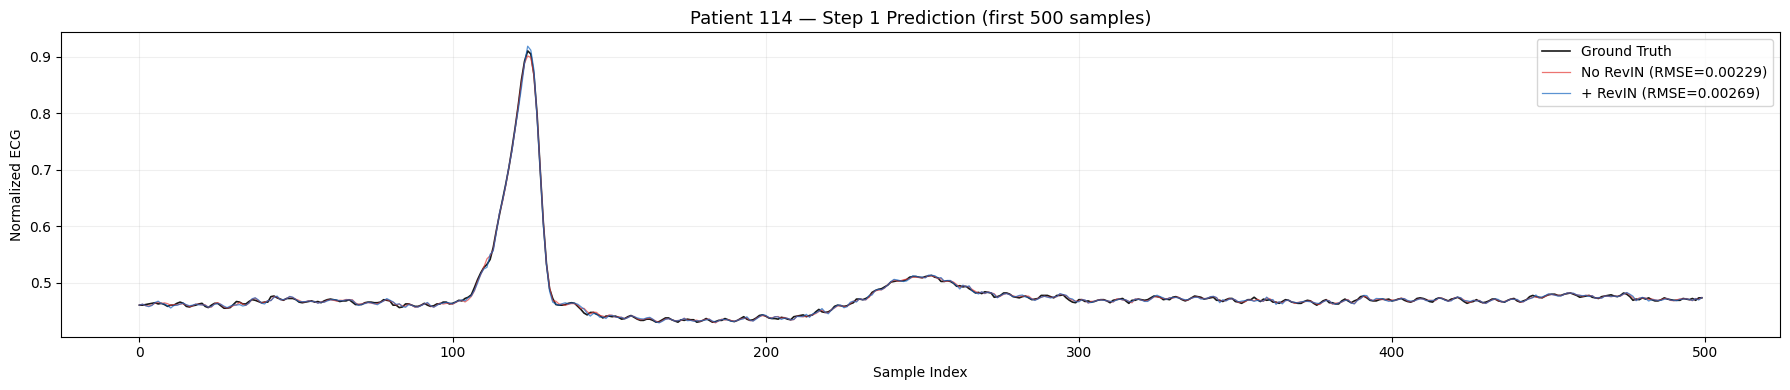

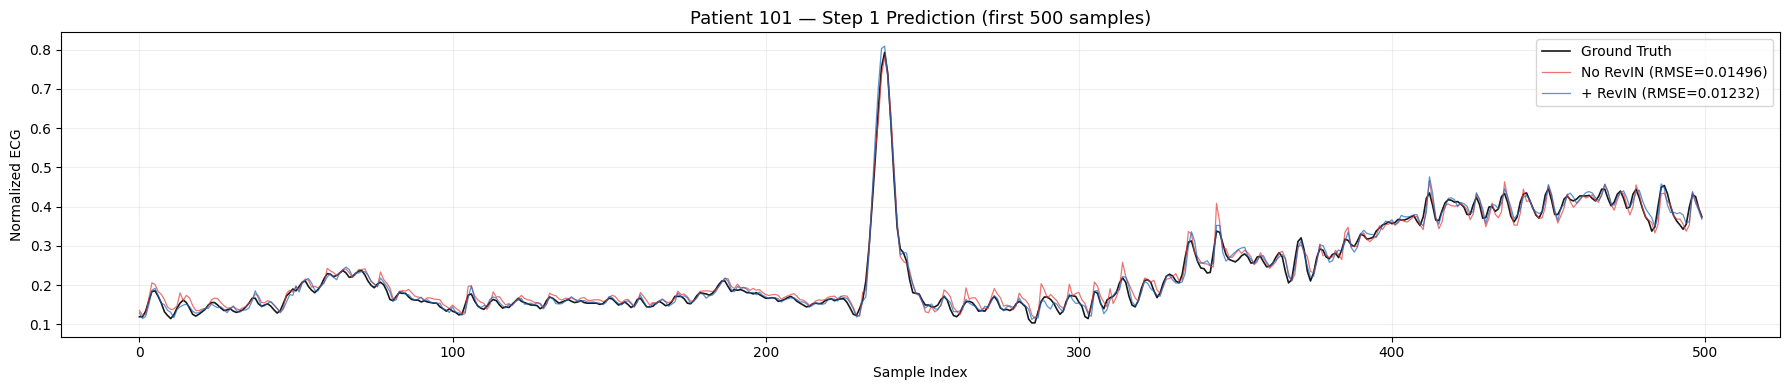

In [16]:
# ── 8.1 Full signal overlay (first 500 test samples, step 0 = next-step pred) ──

for rid in VIZ_PATIENTS:
    y_true_nr, y_pred_nr = preds_no_revin[rid]
    y_true_rv, y_pred_rv = preds_revin[rid]

    # Use step 0 (1-step-ahead from multi-output) for clearest comparison
    N = 500
    gt     = y_true_nr[:N, 0]
    pred_nr = y_pred_nr[:N, 0]
    pred_rv = y_pred_rv[:N, 0]

    rmse_nr = np.sqrt(mean_squared_error(gt, pred_nr))
    rmse_rv = np.sqrt(mean_squared_error(gt, pred_rv))

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(gt, color='black', linewidth=1.2, label='Ground Truth', alpha=0.9)
    ax.plot(pred_nr, color='#E53935', linewidth=0.9, label=f'No RevIN (RMSE={rmse_nr:.5f})', alpha=0.7)
    ax.plot(pred_rv, color='#1565C0', linewidth=0.9, label=f'+ RevIN (RMSE={rmse_rv:.5f})', alpha=0.7)
    ax.set_title(f'Patient {rid} — Step 1 Prediction (first 500 samples)', fontsize=13)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Normalized ECG')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/signal_overlay_{rid}_step1.png', dpi=200, bbox_inches='tight')
    plt.show()

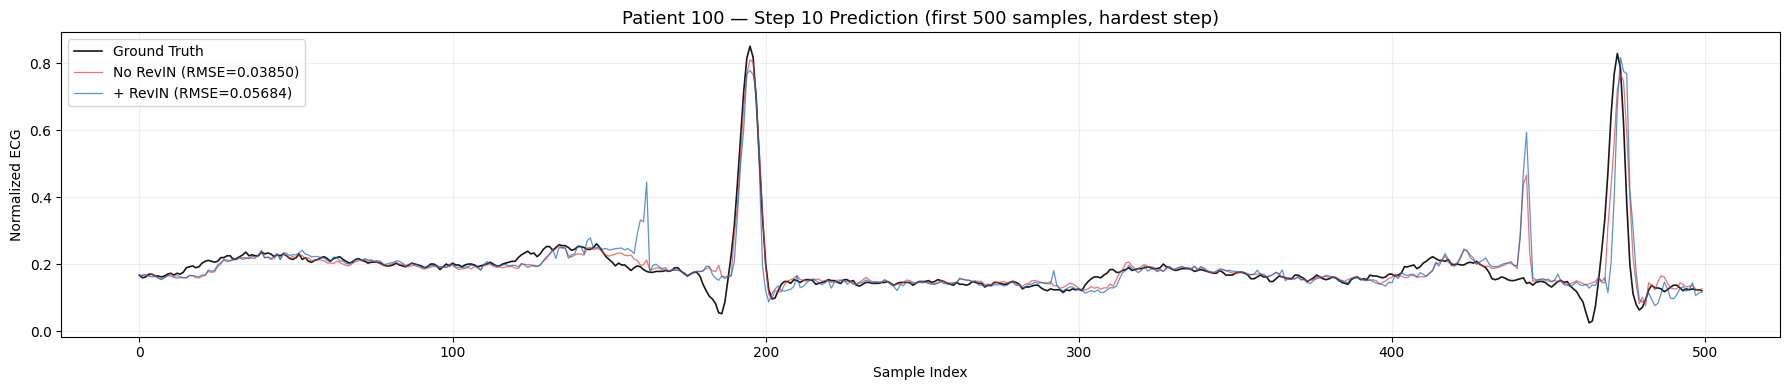

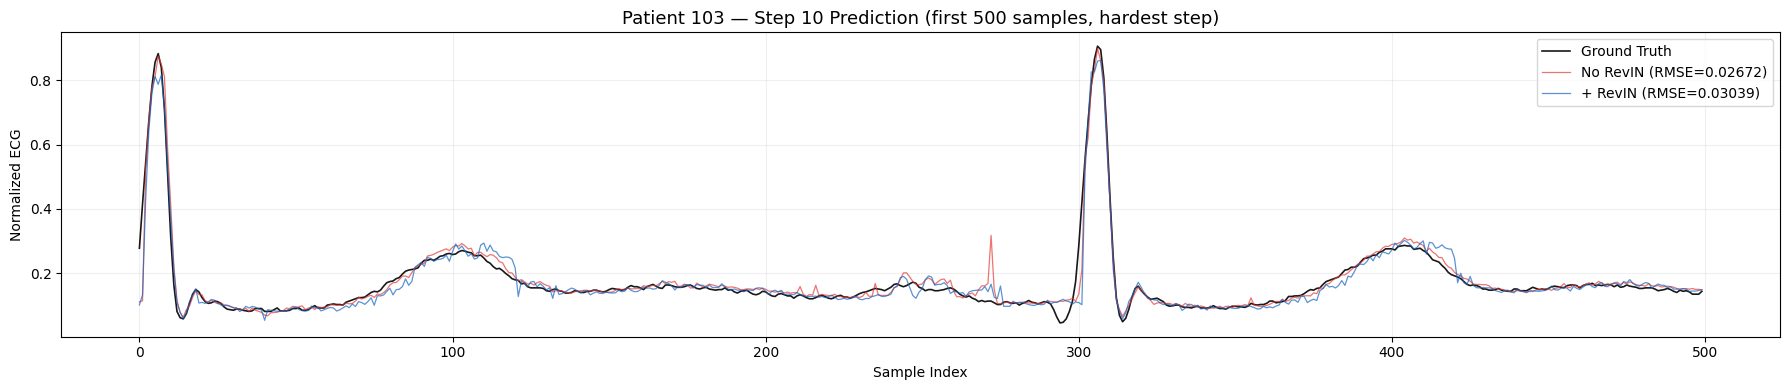

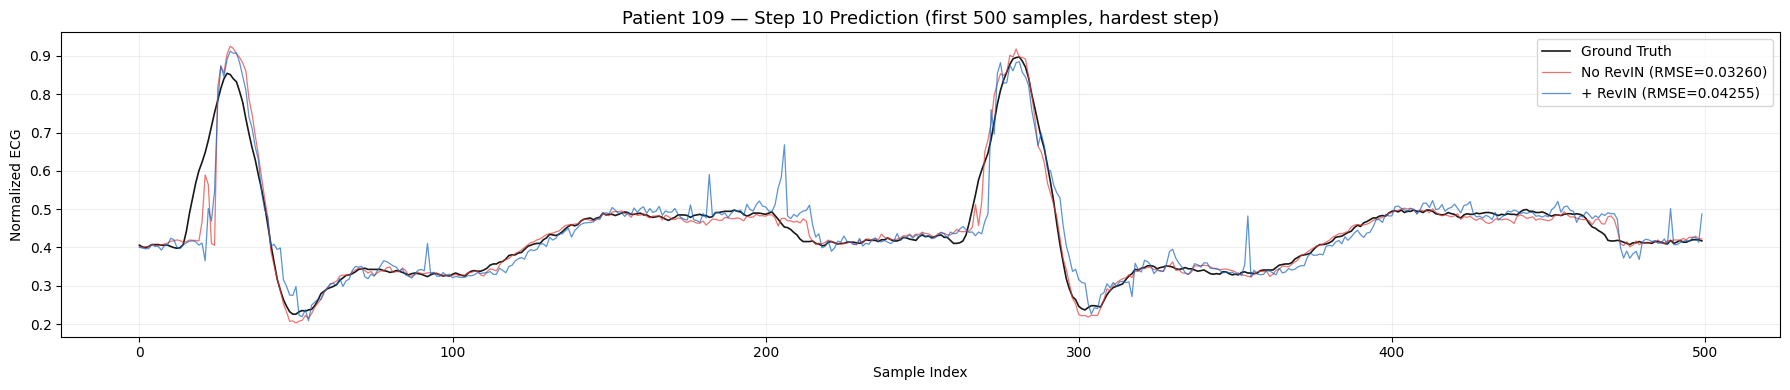

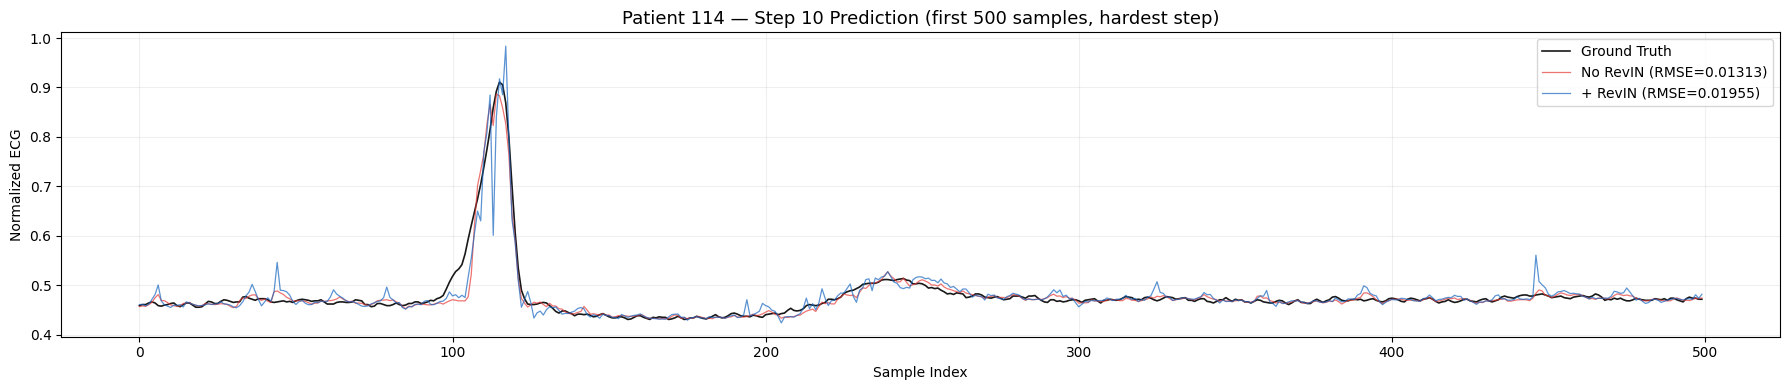

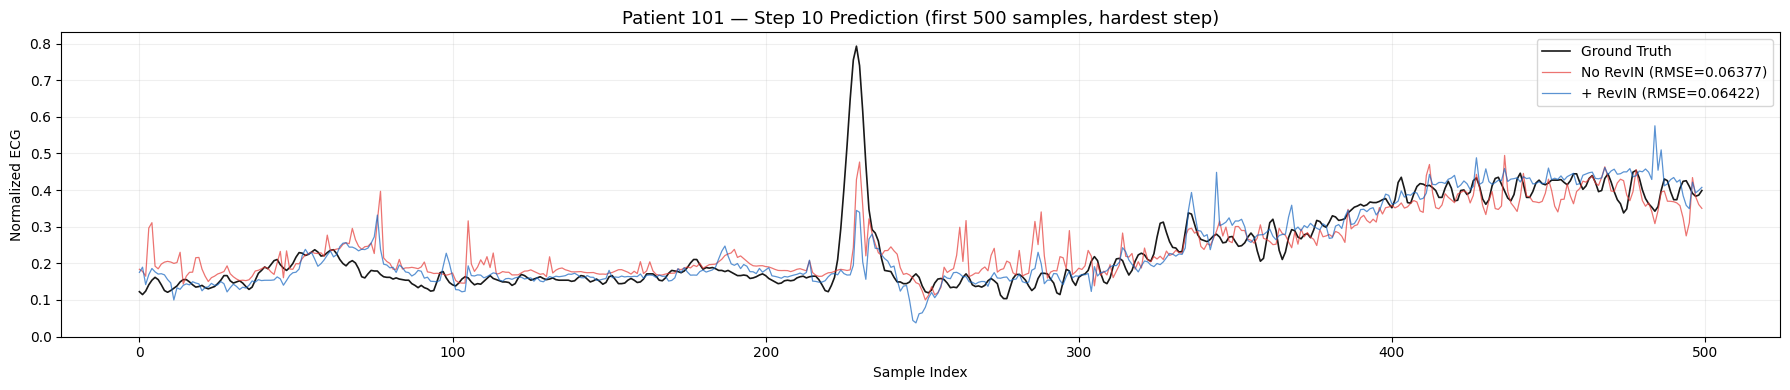

In [17]:
# ── 8.2 Full signal overlay — Step 10 (hardest step, furthest prediction) ──

for rid in VIZ_PATIENTS:
    y_true_nr, y_pred_nr = preds_no_revin[rid]
    y_true_rv, y_pred_rv = preds_revin[rid]

    N = 500
    gt      = y_true_nr[:N, -1]     # last step = step 10
    pred_nr = y_pred_nr[:N, -1]
    pred_rv = y_pred_rv[:N, -1]

    rmse_nr = np.sqrt(mean_squared_error(gt, pred_nr))
    rmse_rv = np.sqrt(mean_squared_error(gt, pred_rv))

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(gt, color='black', linewidth=1.2, label='Ground Truth', alpha=0.9)
    ax.plot(pred_nr, color='#E53935', linewidth=0.9, label=f'No RevIN (RMSE={rmse_nr:.5f})', alpha=0.7)
    ax.plot(pred_rv, color='#1565C0', linewidth=0.9, label=f'+ RevIN (RMSE={rmse_rv:.5f})', alpha=0.7)
    ax.set_title(f'Patient {rid} — Step 10 Prediction (first 500 samples, hardest step)', fontsize=13)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Normalized ECG')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/signal_overlay_{rid}_step10.png', dpi=200, bbox_inches='tight')
    plt.show()

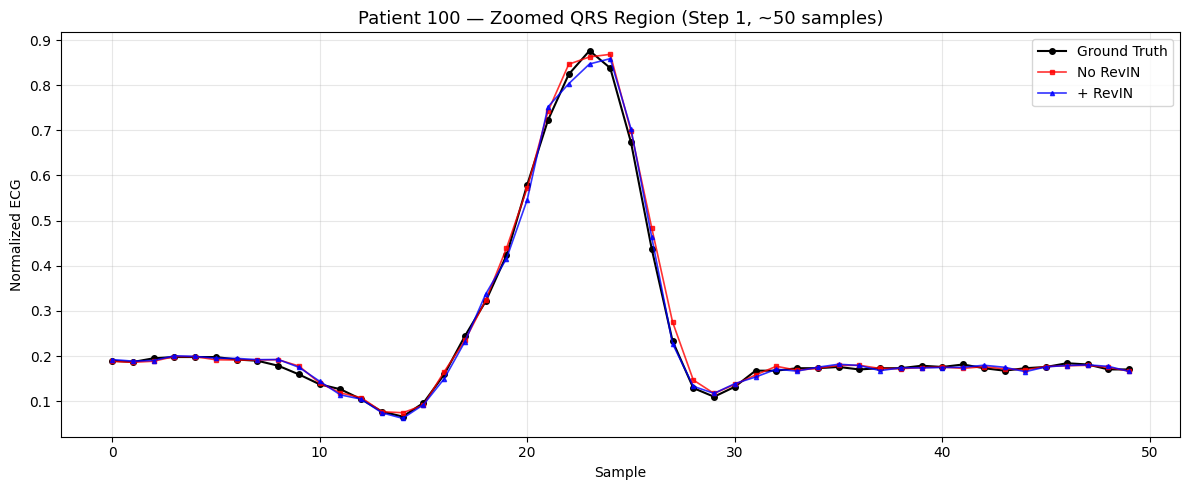

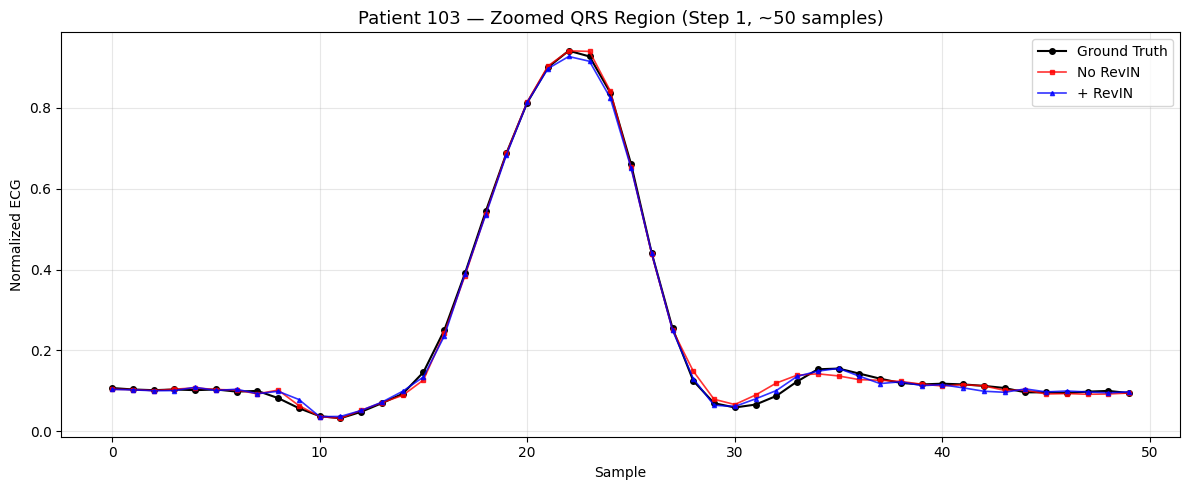

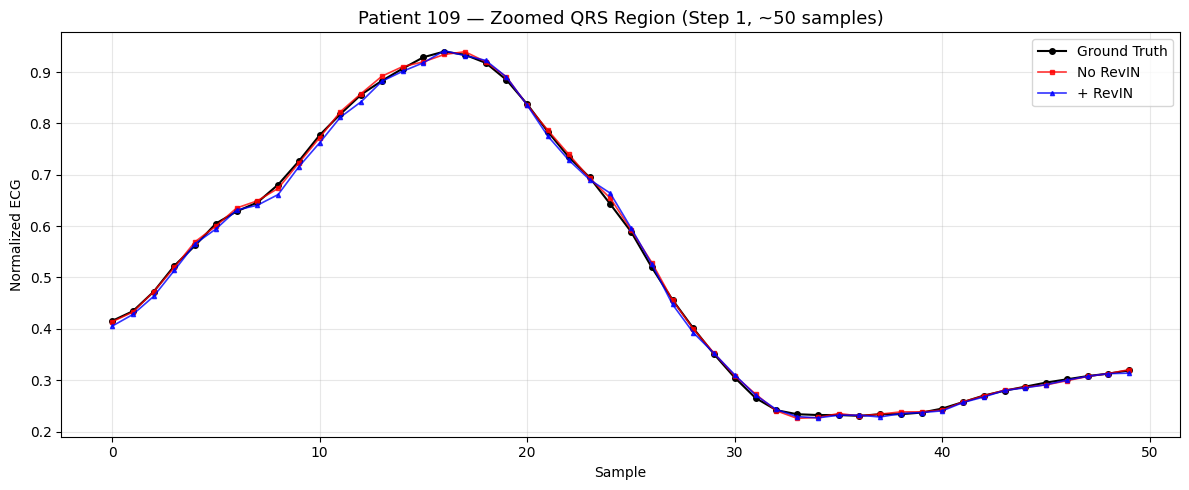

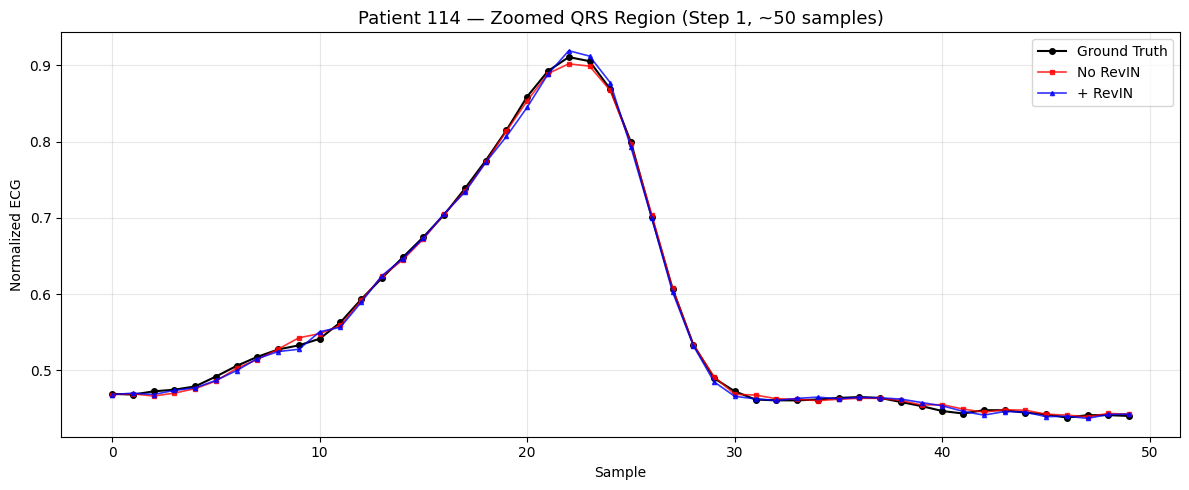

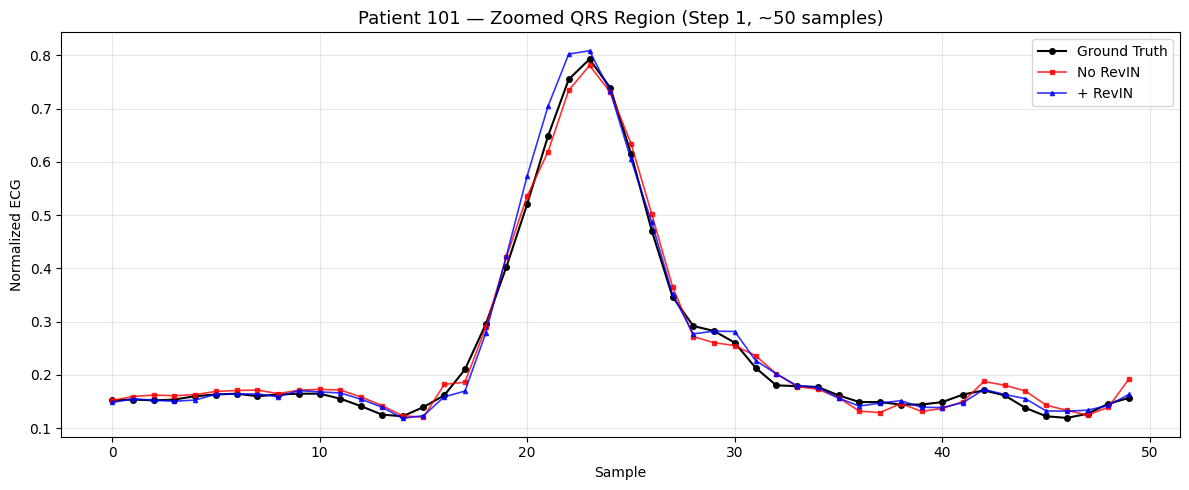

In [18]:
# ── 8.3 Zoomed QRS complex region — Peak tracking quality ─────────────────
# Zoom into 50-sample window around a high-amplitude region (QRS complex)

for rid in VIZ_PATIENTS:
    y_true_nr, y_pred_nr = preds_no_revin[rid]
    y_true_rv, y_pred_rv = preds_revin[rid]

    gt_full = y_true_nr[:2000, 0]
    # Find a QRS peak (high amplitude region)
    peak_idx = np.argmax(np.abs(np.diff(gt_full[:1500])))  # sharpest transition
    start = max(0, peak_idx - 25)
    end   = min(len(gt_full), peak_idx + 25)

    gt      = y_true_nr[start:end, 0]
    pred_nr = y_pred_nr[start:end, 0]
    pred_rv = y_pred_rv[start:end, 0]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(gt, 'k-o', markersize=4, linewidth=1.5, label='Ground Truth')
    ax.plot(pred_nr, 'r-s', markersize=3, linewidth=1.2, label='No RevIN', alpha=0.8)
    ax.plot(pred_rv, 'b-^', markersize=3, linewidth=1.2, label='+ RevIN', alpha=0.8)
    ax.set_title(f'Patient {rid} — Zoomed QRS Region (Step 1, ~50 samples)', fontsize=13)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Normalized ECG')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/zoomed_qrs_{rid}.png', dpi=200, bbox_inches='tight')
    plt.show()

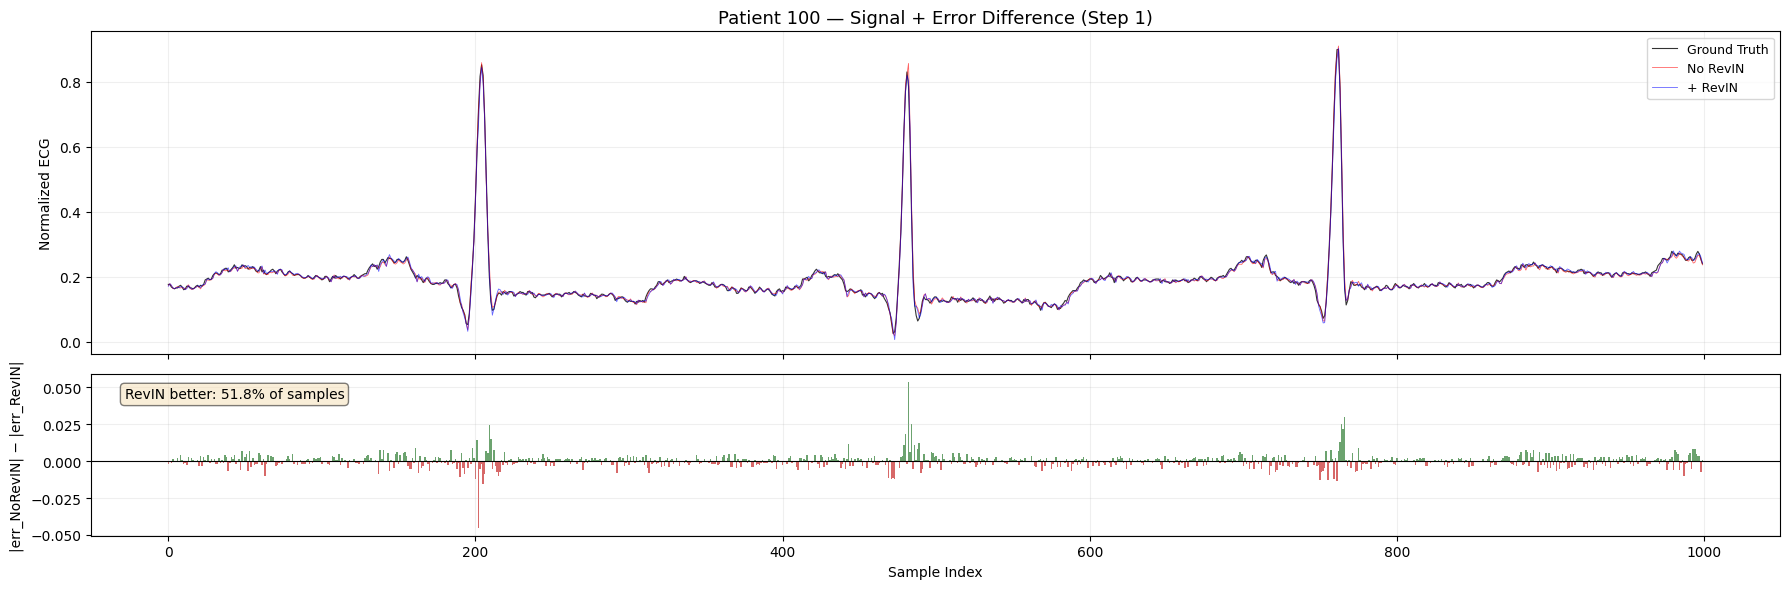

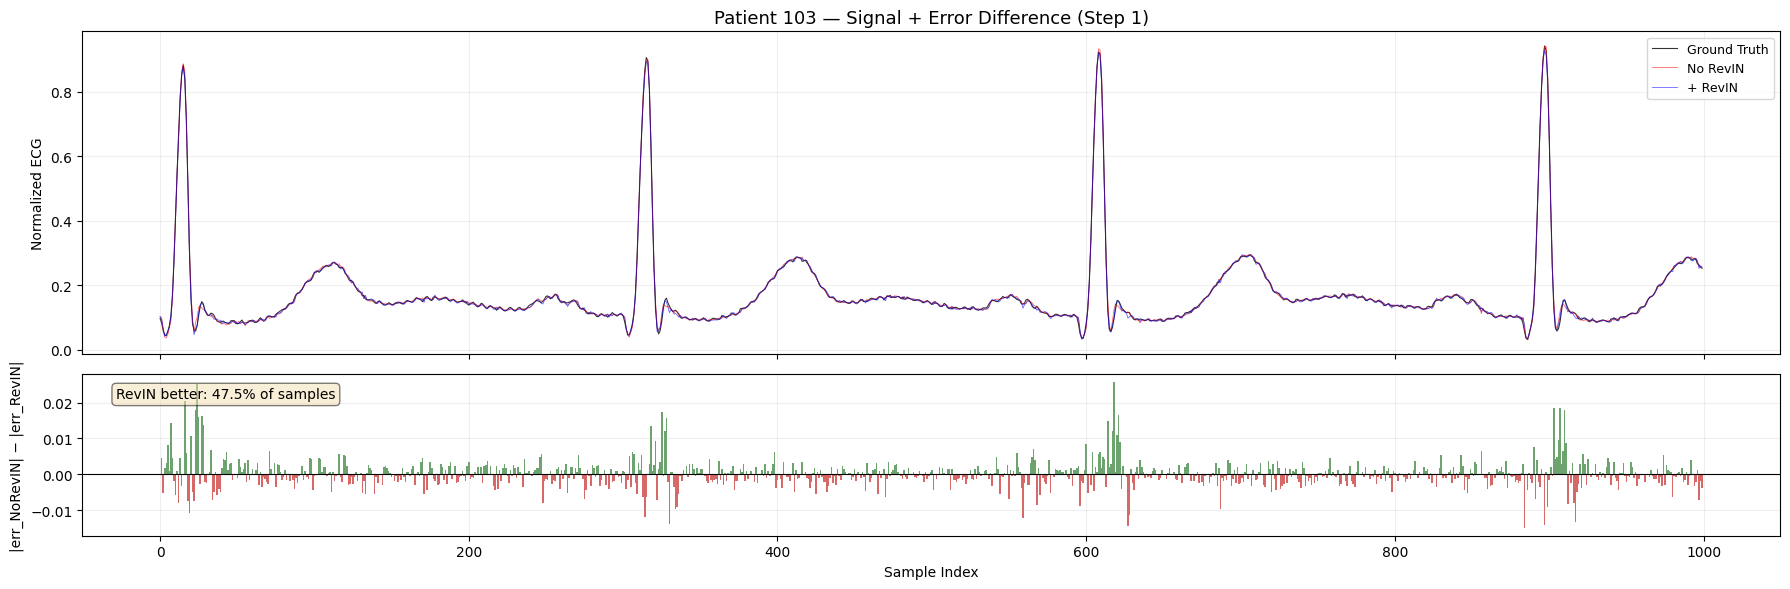

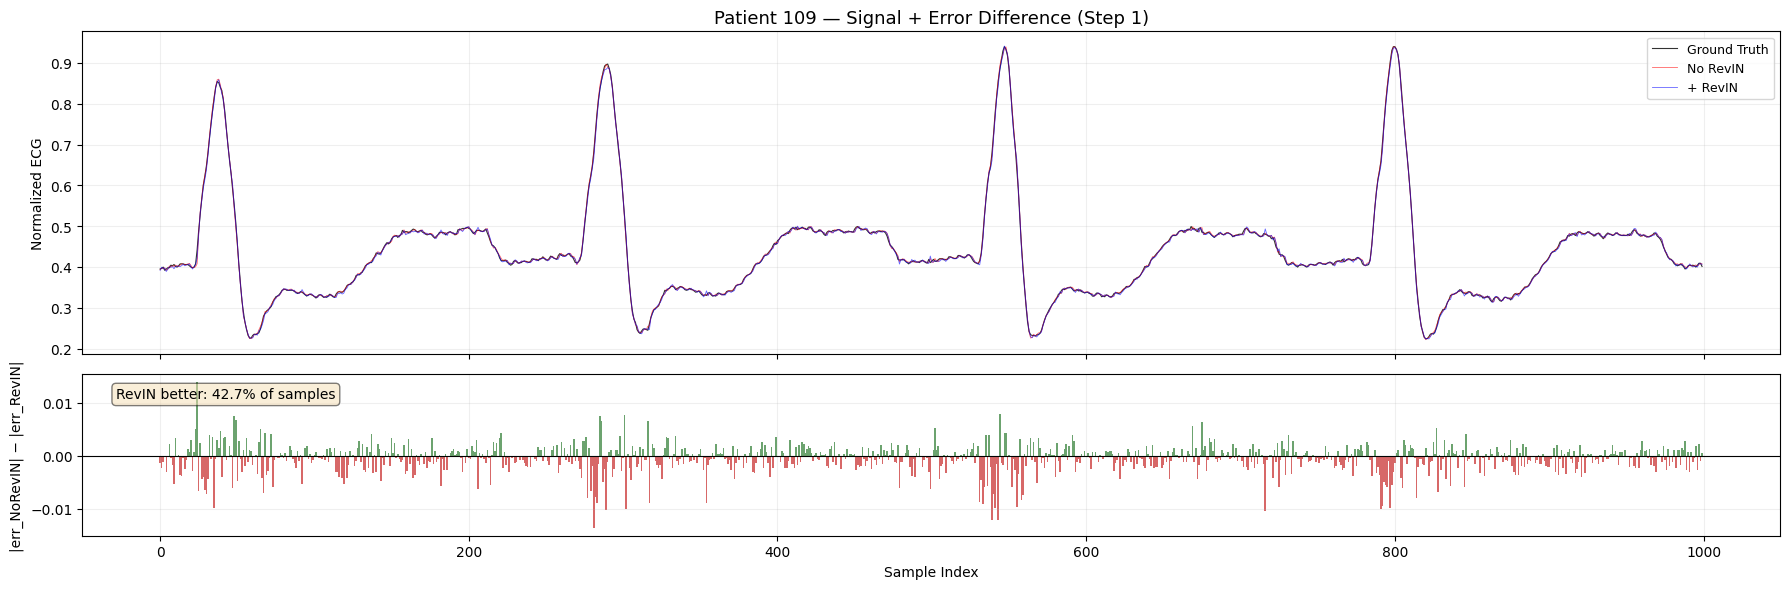

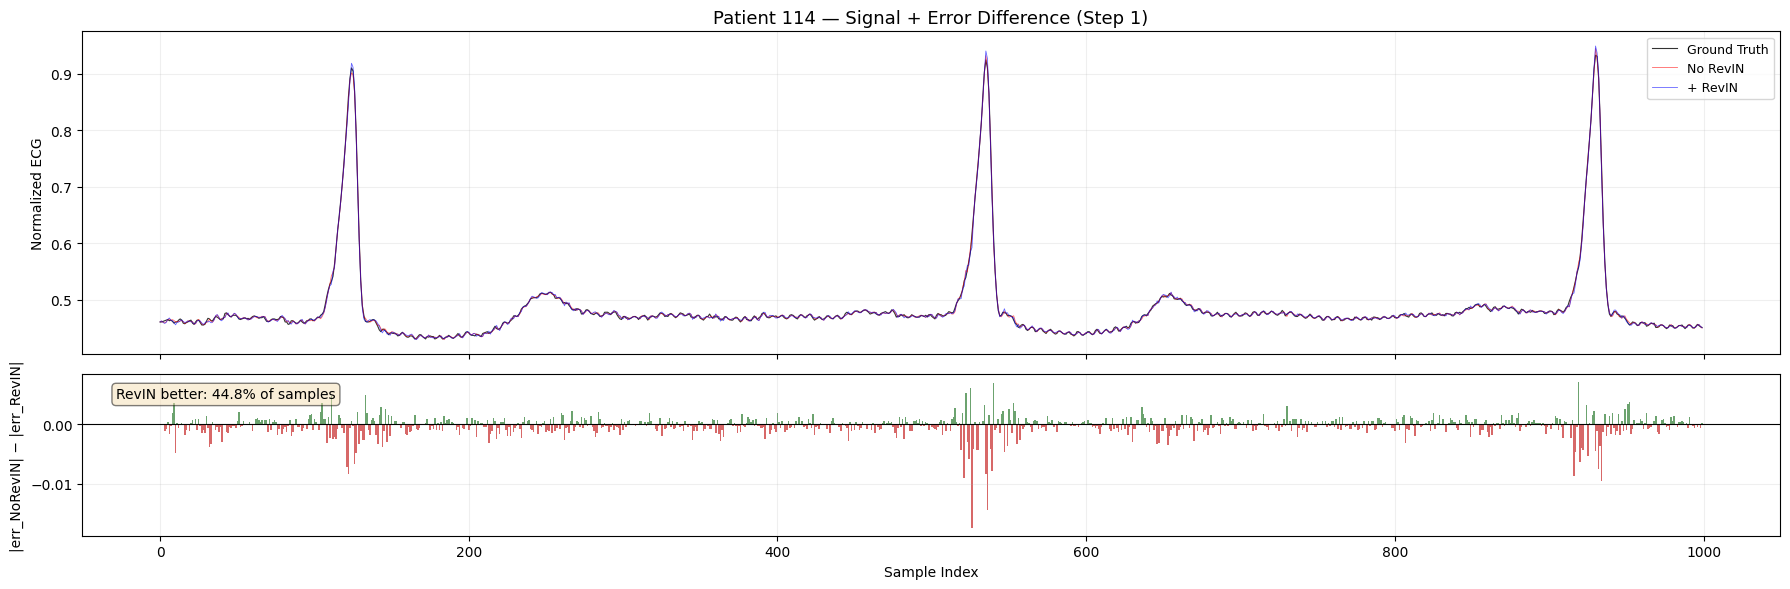

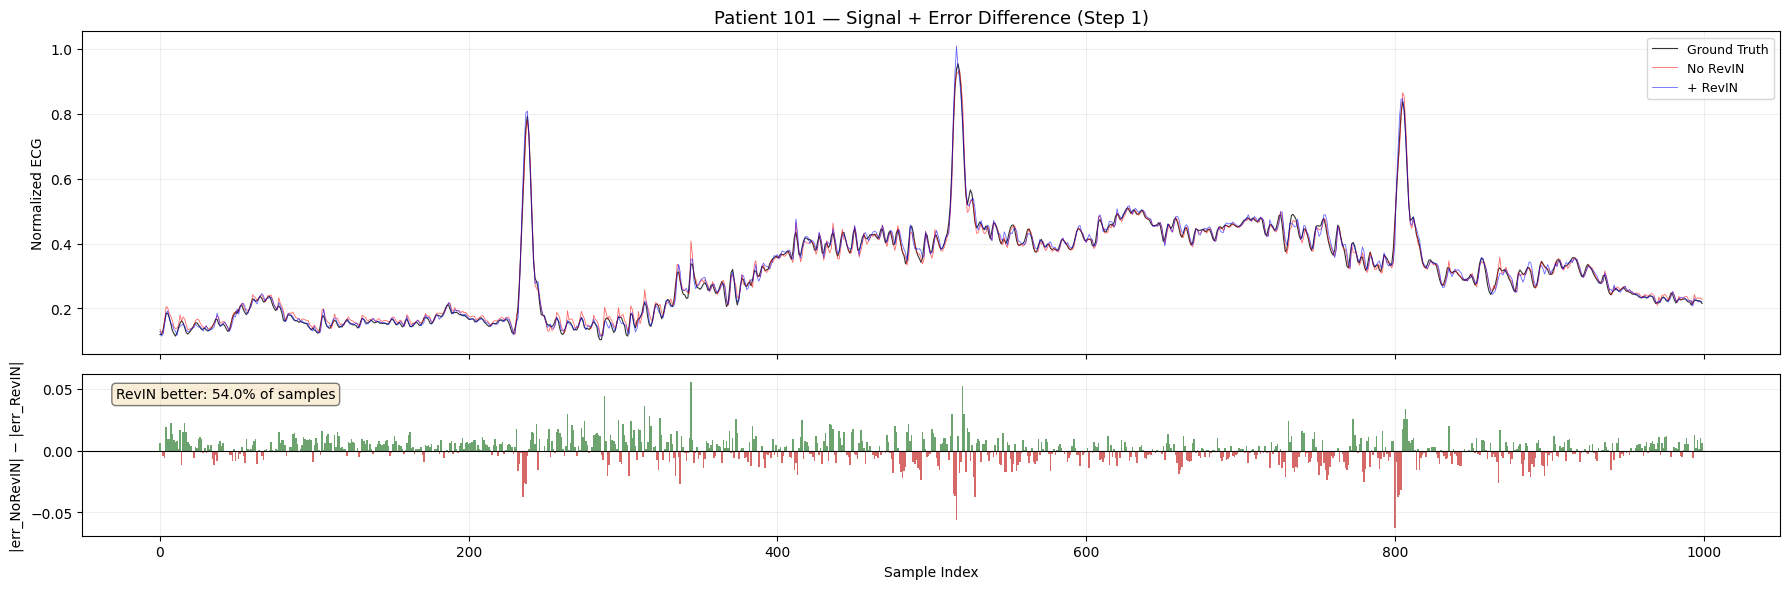

In [19]:
# ── 8.4 Error difference plot — where does RevIN help most? ────────────────

for rid in VIZ_PATIENTS:
    y_true_nr, y_pred_nr = preds_no_revin[rid]
    y_true_rv, y_pred_rv = preds_revin[rid]

    N = 1000
    err_nr = np.abs(y_true_nr[:N, 0] - y_pred_nr[:N, 0])
    err_rv = np.abs(y_true_rv[:N, 0] - y_pred_rv[:N, 0])
    err_diff = err_nr - err_rv  # positive = RevIN has lower error

    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

    # Top: signal + both predictions
    axes[0].plot(y_true_nr[:N, 0], 'k-', linewidth=0.8, label='Ground Truth', alpha=0.8)
    axes[0].plot(y_pred_nr[:N, 0], 'r-', linewidth=0.6, label='No RevIN', alpha=0.6)
    axes[0].plot(y_pred_rv[:N, 0], 'b-', linewidth=0.6, label='+ RevIN', alpha=0.6)
    axes[0].set_ylabel('Normalized ECG')
    axes[0].legend(fontsize=9, loc='upper right')
    axes[0].set_title(f'Patient {rid} — Signal + Error Difference (Step 1)', fontsize=13)
    axes[0].grid(alpha=0.2)

    # Bottom: error difference (positive = RevIN wins)
    colors = np.where(err_diff > 0, '#2E7D32', '#C62828')
    axes[1].bar(range(N), err_diff, color=colors, width=1.0, alpha=0.7)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_ylabel('|err_NoRevIN| − |err_RevIN|')
    axes[1].set_xlabel('Sample Index')
    axes[1].grid(alpha=0.2)

    # Annotate: what fraction of samples RevIN wins
    pct_revin_wins = (err_diff > 0).mean() * 100
    axes[1].text(0.02, 0.85, f'RevIN better: {pct_revin_wins:.1f}% of samples',
                transform=axes[1].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/error_diff_{rid}.png', dpi=200, bbox_inches='tight')
    plt.show()

## 9 — Per-Step RMSE Comparison (averaged over all patients)

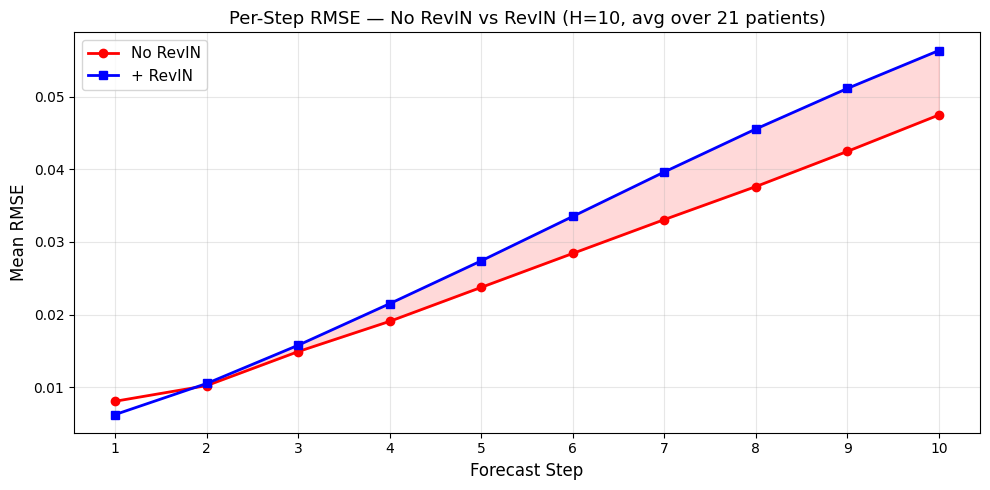

 Step   No RevIN     +RevIN       Δ%
    1   0.008065   0.006238  -22.65%
    2   0.010218   0.010511   +2.87%
    3   0.014903   0.015776   +5.86%
    4   0.019065   0.021499  +12.77%
    5   0.023740   0.027392  +15.38%
    6   0.028409   0.033502  +17.93%
    7   0.033063   0.039620  +19.83%
    8   0.037608   0.045533  +21.07%
    9   0.042450   0.051112  +20.40%
   10   0.047460   0.056332  +18.69%


In [20]:
# ── Compute per-step RMSE for both models ─────────────────────────────────
step_rmse_nr = np.zeros(HORIZON)
step_rmse_rv = np.zeros(HORIZON)

for rid in PATIENTS:
    y_true_nr, y_pred_nr = preds_no_revin[rid]
    y_true_rv, y_pred_rv = preds_revin[rid]
    for h in range(HORIZON):
        step_rmse_nr[h] += np.sqrt(mean_squared_error(y_true_nr[:, h], y_pred_nr[:, h]))
        step_rmse_rv[h] += np.sqrt(mean_squared_error(y_true_rv[:, h], y_pred_rv[:, h]))

step_rmse_nr /= len(PATIENTS)
step_rmse_rv /= len(PATIENTS)

fig, ax = plt.subplots(figsize=(10, 5))
steps = range(1, HORIZON + 1)
ax.plot(steps, step_rmse_nr, 'r-o', markersize=6, linewidth=2, label='No RevIN')
ax.plot(steps, step_rmse_rv, 'b-s', markersize=6, linewidth=2, label='+ RevIN')
ax.fill_between(steps, step_rmse_nr, step_rmse_rv, alpha=0.15, color='green',
                where=(step_rmse_nr > step_rmse_rv))
ax.fill_between(steps, step_rmse_nr, step_rmse_rv, alpha=0.15, color='red',
                where=(step_rmse_nr < step_rmse_rv))
ax.set_xlabel('Forecast Step', fontsize=12)
ax.set_ylabel('Mean RMSE', fontsize=12)
ax.set_title(f'Per-Step RMSE — No RevIN vs RevIN (H={HORIZON}, avg over {len(PATIENTS)} patients)', fontsize=13)
ax.set_xticks(steps)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_rmse_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Print per-step improvement
print(f'{"Step":>5} {"No RevIN":>10} {"+RevIN":>10} {"Δ%":>8}')
for h in range(HORIZON):
    pct = (step_rmse_rv[h] - step_rmse_nr[h]) / step_rmse_nr[h] * 100
    print(f'{h+1:>5} {step_rmse_nr[h]:>10.6f} {step_rmse_rv[h]:>10.6f} {pct:>+7.2f}%')

## 10 — Raw ECG Signal Visualization (Before Any Model)

Show what the actual ECG signals look like for the visualization patients,
so the reader can appreciate the signal complexity.

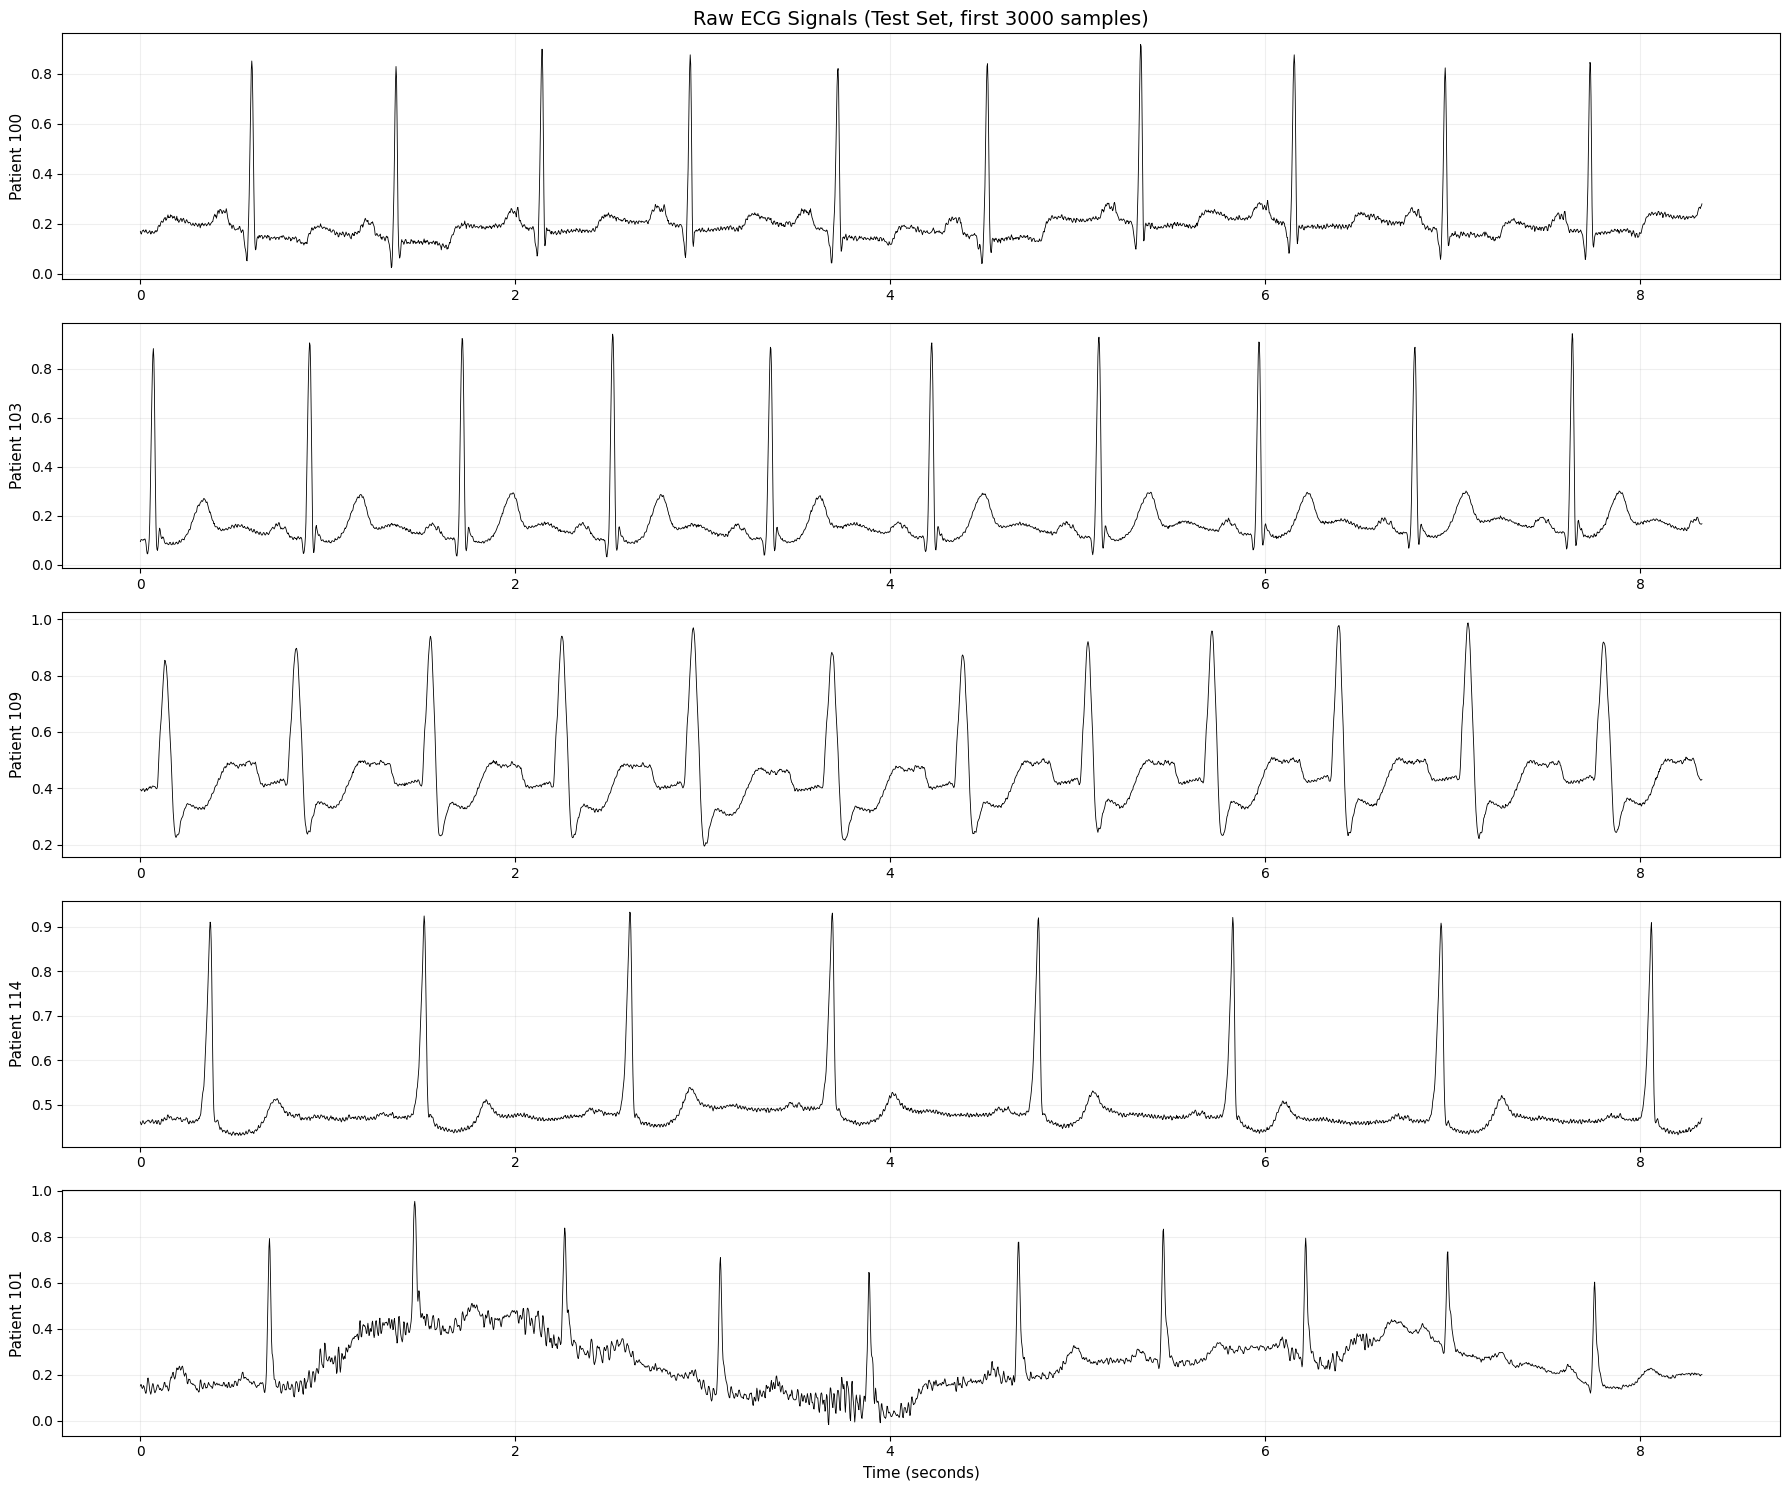

In [21]:
# ── Raw ECG waveform for viz patients ─────────────────────────────────────
fig, axes = plt.subplots(len(VIZ_PATIENTS), 1, figsize=(18, 3 * len(VIZ_PATIENTS)))

for idx, rid in enumerate(VIZ_PATIENTS):
    ax = axes[idx]
    test_signal = patient_signals[rid]['test'][:3000]
    time_axis = np.arange(len(test_signal)) / FS  # seconds
    ax.plot(time_axis, test_signal, 'k-', linewidth=0.6)
    ax.set_ylabel(f'Patient {rid}', fontsize=11)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.set_title('Raw ECG Signals (Test Set, first 3000 samples)', fontsize=14)
    if idx == len(VIZ_PATIENTS) - 1:
        ax.set_xlabel('Time (seconds)', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/raw_ecg_signals.png', dpi=200, bbox_inches='tight')
plt.show()

## 11 — Training Loss Curves Comparison

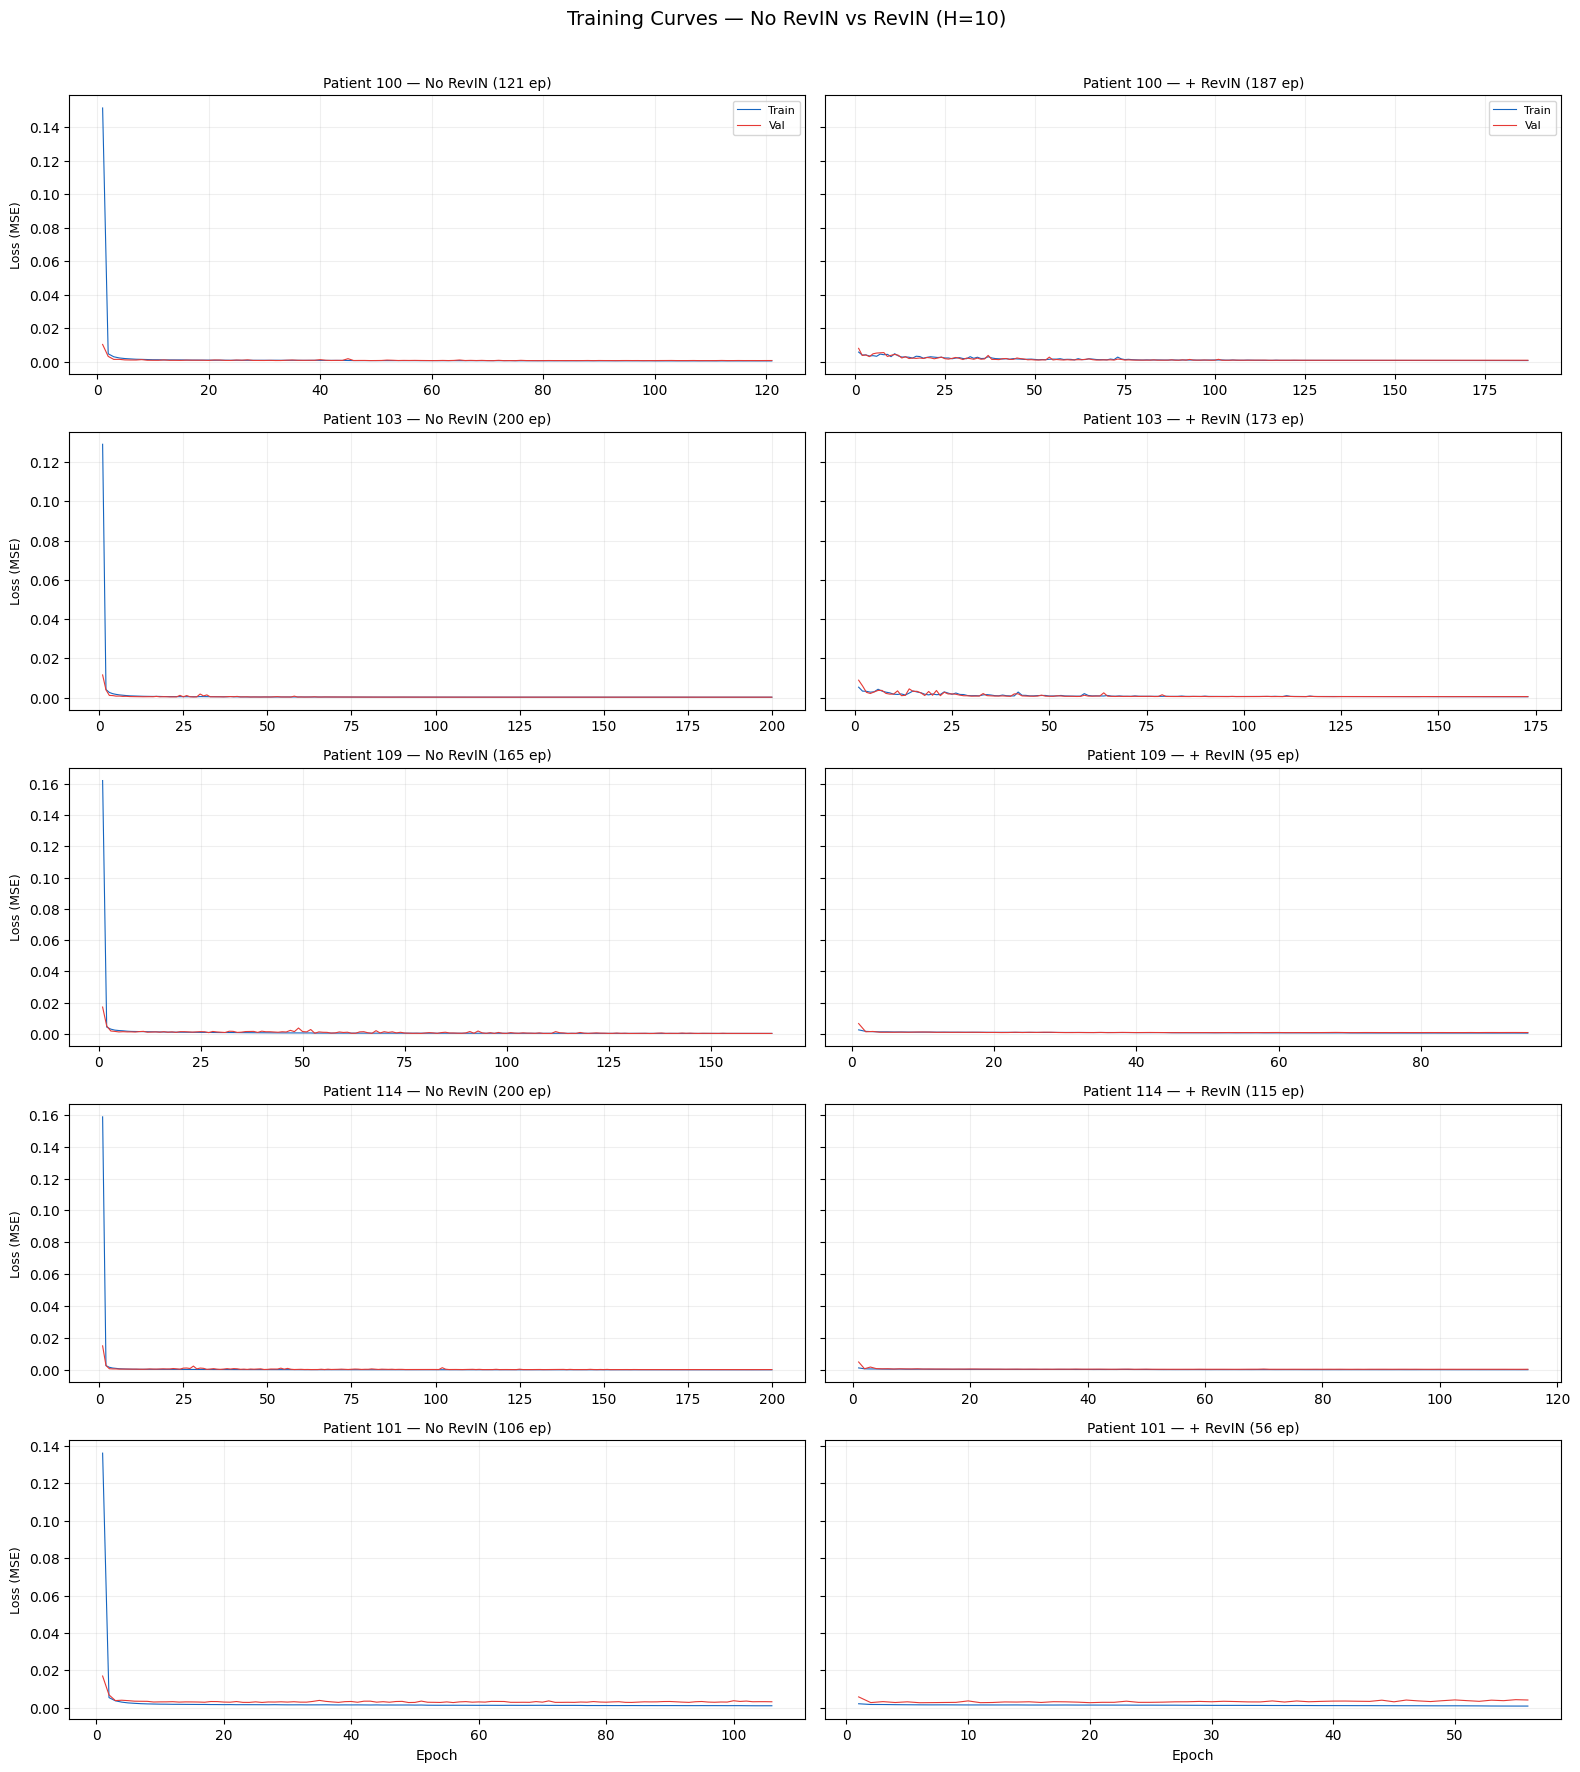

In [22]:
# ── Side-by-side training curves for viz patients ──────────────────────────
fig, axes = plt.subplots(len(VIZ_PATIENTS), 2, figsize=(16, 3.5 * len(VIZ_PATIENTS)),
                         sharey='row')

for idx, rid in enumerate(VIZ_PATIENTS):
    # No RevIN
    ax_nr = axes[idx, 0]
    h_nr = hist_no_revin[rid]
    ep_nr = range(1, len(h_nr['loss']) + 1)
    ax_nr.plot(ep_nr, h_nr['loss'], label='Train', linewidth=0.8, color='#1565C0')
    ax_nr.plot(ep_nr, h_nr['val_loss'], label='Val', linewidth=0.8, color='#E53935')
    ax_nr.set_title(f'Patient {rid} — No RevIN ({len(h_nr["loss"])} ep)', fontsize=10)
    ax_nr.set_ylabel('Loss (MSE)', fontsize=9)
    ax_nr.grid(alpha=0.2)
    if idx == 0:
        ax_nr.legend(fontsize=8)

    # RevIN
    ax_rv = axes[idx, 1]
    h_rv = hist_revin[rid]
    ep_rv = range(1, len(h_rv['loss']) + 1)
    ax_rv.plot(ep_rv, h_rv['loss'], label='Train', linewidth=0.8, color='#1565C0')
    ax_rv.plot(ep_rv, h_rv['val_loss'], label='Val', linewidth=0.8, color='#E53935')
    ax_rv.set_title(f'Patient {rid} — + RevIN ({len(h_rv["loss"])} ep)', fontsize=10)
    ax_rv.grid(alpha=0.2)
    if idx == 0:
        ax_rv.legend(fontsize=8)

    if idx == len(VIZ_PATIENTS) - 1:
        ax_nr.set_xlabel('Epoch')
        ax_rv.set_xlabel('Epoch')

plt.suptitle(f'Training Curves — No RevIN vs RevIN (H={HORIZON})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/training_curves_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 12 — Scatter: No RevIN vs RevIN RMSE per Patient

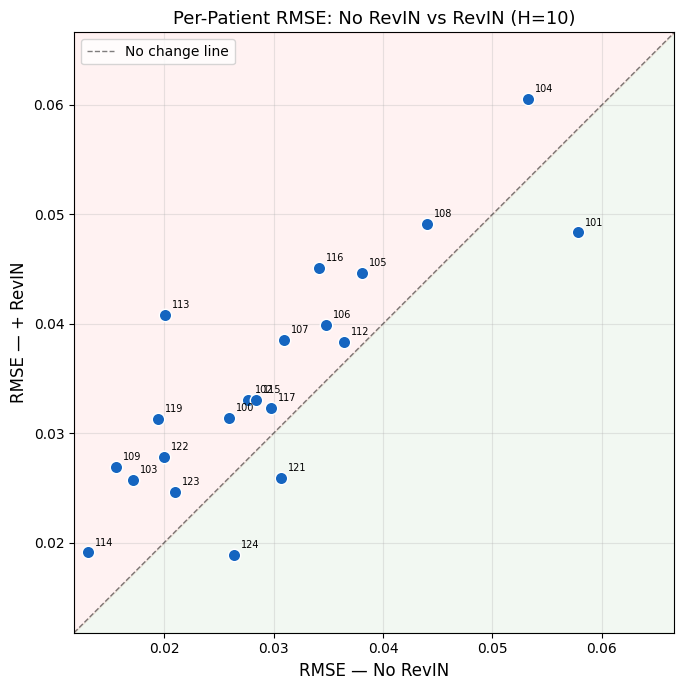

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))

rmse_nr = df_no_revin.RMSE.values
rmse_rv = df_revin.RMSE.values

ax.scatter(rmse_nr, rmse_rv, s=80, c='#1565C0', edgecolors='white', zorder=3)

# Identity line (no change)
lims = [min(rmse_nr.min(), rmse_rv.min()) * 0.9,
        max(rmse_nr.max(), rmse_rv.max()) * 1.1]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='No change line')

# Label each point
for i, rid in enumerate(PATIENTS):
    ax.annotate(rid, (rmse_nr[i], rmse_rv[i]), fontsize=7,
                textcoords='offset points', xytext=(5, 5))

ax.set_xlabel('RMSE — No RevIN', fontsize=12)
ax.set_ylabel('RMSE — + RevIN', fontsize=12)
ax.set_title(f'Per-Patient RMSE: No RevIN vs RevIN (H={HORIZON})', fontsize=13)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_aspect('equal')

# Shade regions
ax.fill_between(lims, lims, lims[0], alpha=0.05, color='green', label='RevIN better')
ax.fill_between(lims, lims, lims[1], alpha=0.05, color='red', label='RevIN worse')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/scatter_rmse.png', dpi=200, bbox_inches='tight')
plt.show()

## 13 — Final Verdict

In [24]:
print('=' * 70)
print('  FINAL COMPARISON: GWO-Optimized TCN — No RevIN vs + RevIN')
print('=' * 70)
print(f'\n  Horizon: H={HORIZON}')
print(f'  Config : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, dropout={DROPOUT_RATE}, lr={LEARNING_RATE}')
print(f'  Patients: {len(PATIENTS)}')
print()

for metric in ['RMSE', 'MAE', 'R2']:
    nr = df_no_revin[metric].mean()
    wr = df_revin[metric].mean()
    pct = (wr - nr) / nr * 100
    better = 'RevIN ✓' if (pct < 0 and metric != 'R2') or (pct > 0 and metric == 'R2') else 'No RevIN ✓'
    print(f'  {metric:>6}: No RevIN={nr:.6f}  +RevIN={wr:.6f}  Δ={pct:+.2f}%  → {better}')

print(f'\n  Patients where RevIN improved RMSE: {improved}/{len(PATIENTS)}')
print(f'  Wilcoxon p-value: {p:.4f} ({sig})')
print()
print('  Key visual observations:')
print('  - Check signal overlay plots above to see if improvements')
print('    are in peak tracking, baseline stability, or both.')
print('  - Error difference plots show WHERE RevIN helps/hurts per sample.')
print('  - Zoomed QRS plots reveal peak amplitude tracking quality.')

  FINAL COMPARISON: GWO-Optimized TCN — No RevIN vs + RevIN

  Horizon: H=10
  Config : blocks=4, filters=256, dropout=0.109, lr=0.002066
  Patients: 21

    RMSE: No RevIN=0.029743  +RevIN=0.035015  Δ=+17.72%  → No RevIN ✓
     MAE: No RevIN=0.012957  +RevIN=0.014893  Δ=+14.94%  → No RevIN ✓
      R2: No RevIN=0.903389  +RevIN=0.872504  Δ=-3.42%  → No RevIN ✓

  Patients where RevIN improved RMSE: 3/21
  Wilcoxon p-value: 0.0038 (✓ Significant)

  Key visual observations:
  - Check signal overlay plots above to see if improvements
    are in peak tracking, baseline stability, or both.
  - Error difference plots show WHERE RevIN helps/hurts per sample.
  - Zoomed QRS plots reveal peak amplitude tracking quality.
